

# Prepatre und Setup



Below code for mount the g drive

In [2]:
from google.colab import drive
drive.mount("/content/drive")

Mounted at /content/drive


In [ ]:
from pathlib import Path

PROJECT_DIR = Path("/content/drive/MyDrive/speedcube-colour-drifting")
ZIP_PATH = PROJECT_DIR / "dataset.zip"

WORK_DIR = Path("/content")
DATA_DIR = WORK_DIR / "data"
ROI_DIR = DATA_DIR / "roi"

PROCESSED_DIR = PROJECT_DIR / "processed"
MODELS_DIR = PROJECT_DIR / "models"
RESULTS_DIR = PROJECT_DIR / "results"

for path in [PROCESSED_DIR, MODELS_DIR, RESULTS_DIR]:
    path.mkdir(parents=True, exist_ok=True)

print("PROJECT_DIR:", PROJECT_DIR)
print("ZIP_PATH exists:", ZIP_PATH.exists())

PROJECT_DIR: /content/drive/MyDrive/speedcube-colour-drifting
ZIP_PATH exists: True


Below code for unzip and palce it in the runtime

In [ ]:
import shutil
from pathlib import Path

LOCAL_ZIP = Path("/content/dataset.zip")

if not LOCAL_ZIP.exists():
    print("Copying dataset.zip from Drive to /content...")
    shutil.copy(ZIP_PATH, LOCAL_ZIP)

if not ROI_DIR.exists():
    print("Unzipping dataset...")
    !unzip -q /content/dataset.zip -d /content

print("ROI_DIR:", ROI_DIR)
print("ROI_DIR exists:", ROI_DIR.exists())

Copying dataset.zip from Drive to /content...
Unzipping dataset...
ROI_DIR: /content/data/roi
ROI_DIR exists: True


Now, install some library needed


In [ ]:
!pip install -q numpy pandas matplotlib tqdm joblib opencv-python scikit-learn albumentations
!pip install -q torch torchvision

Nw some import and init config


In [ ]:
import re
import time
import json
import random
from pathlib import Path

import cv2
import joblib
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from tqdm.auto import tqdm

import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader

from sklearn.model_selection import GridSearchCV
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.pipeline import Pipeline
from sklearn.svm import SVC
from sklearn.metrics import (
    accuracy_score,
    precision_recall_fscore_support,
    classification_report,
    confusion_matrix,
)

RANDOM_STATE = 42

LABELS = ["white", "yellow", "red", "orange", "blue", "green"]

random.seed(RANDOM_STATE)
np.random.seed(RANDOM_STATE)
torch.manual_seed(RANDOM_STATE)

DEVICE = "cuda" if torch.cuda.is_available() else "cpu"
print("DEVICE:", DEVICE)

DEVICE: cuda


Below for creating metadata

In [ ]:
IMAGE_EXTENSIONS = {".jpg", ".jpeg", ".png", ".webp"}

def parse_image_id(stem: str) -> str:
    """
    Contoh:
    red_001_r0_c0 -> red_001
    blue_025_r2_c1 -> blue_025
    """
    match = re.match(r"(.+)_r\d+_c\d+$", stem)
    if match:
        return match.group(1)
    return stem

def parse_row_col(stem: str):
    match = re.search(r"_r(\d+)_c(\d+)$", stem)
    if match:
        return int(match.group(1)), int(match.group(2))
    return None, None

records = []

for label in LABELS:
    label_dir = ROI_DIR / label

    if not label_dir.exists():
        print(f"[WARN] Folder tidak ditemukan: {label_dir}")
        continue

    paths = [
        p for p in label_dir.iterdir()
        if p.is_file() and p.suffix.lower() in IMAGE_EXTENSIONS
    ]

    for path in sorted(paths):
        sample_id = path.stem
        raw_image_id = parse_image_id(sample_id)
        row, col = parse_row_col(sample_id)

        # Prefix label agar image_id antar folder tidak bentrok.
        image_id = f"{label}_{raw_image_id}"

        records.append({
            "sample_id": sample_id,
            "image_id": image_id,
            "row": row,
            "col": col,
            "label": label,
            "roi_path": str(path),
            "is_augmented": False,
            "source_id": sample_id,
        })

df = pd.DataFrame(records)

print("Total ROI:", len(df))
print("\nDistribusi kelas:")
print(df["label"].value_counts().sort_index())

print("\nJumlah source image per kelas:")
print(df.groupby("label")["image_id"].nunique())

Total ROI: 1350

Distribusi kelas:
label
blue      225
green     225
orange    225
red       225
white     225
yellow    225
Name: count, dtype: int64

Jumlah source image per kelas:
label
blue      25
green     25
orange    25
red       25
white     25
yellow    25
Name: image_id, dtype: int64


Below for split


In [ ]:
split_map = {}

for label in LABELS:
    label_df = df[df["label"] == label]
    image_ids = label_df["image_id"].drop_duplicates().to_numpy()

    rng = np.random.default_rng(RANDOM_STATE)
    rng.shuffle(image_ids)

    n_total = len(image_ids)

    n_train = 17
    n_val = 4
    n_test = n_total - n_train - n_val

    assert n_test > 0, f"Jumlah image_id untuk label {label} terlalu sedikit."

    train_ids = image_ids[:n_train]
    val_ids = image_ids[n_train:n_train + n_val]
    test_ids = image_ids[n_train + n_val:]

    for image_id in train_ids:
        split_map[image_id] = "train"

    for image_id in val_ids:
        split_map[image_id] = "val"

    for image_id in test_ids:
        split_map[image_id] = "test"

df["split"] = df["image_id"].map(split_map)

print(pd.crosstab(df["label"], df["split"]))

split   test  train  val
label                   
blue      36    153   36
green     36    153   36
orange    36    153   36
red       36    153   36
white     36    153   36
yellow    36    153   36


In [ ]:
leak_check = df.groupby("image_id")["split"].nunique()
leaky = leak_check[leak_check > 1]

if len(leaky) == 0:
    print("[OK] Tidak ada image_id yang masuk lebih dari satu split.")
else:
    print("[ERROR] Ada leakage:")
    print(leaky)

[OK] Tidak ada image_id yang masuk lebih dari satu split.


In [ ]:
METADATA_SPLIT_PATH = PROCESSED_DIR / "metadata_split.csv"
df.to_csv(METADATA_SPLIT_PATH, index=False)
print("Saved:", METADATA_SPLIT_PATH)

Saved: /content/drive/MyDrive/speedcube-colour-drifting/processed/metadata_split.csv


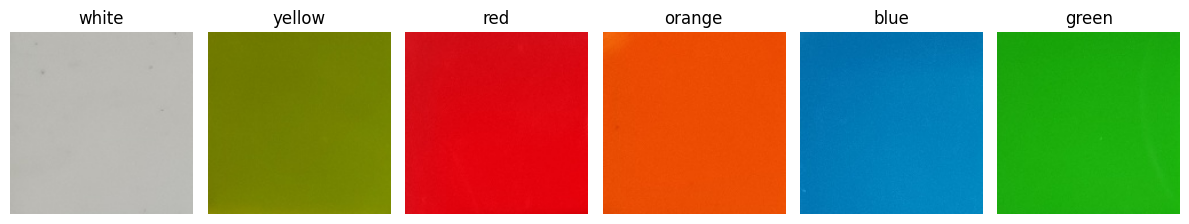

In [ ]:
sample_df = df.groupby("label").head(1)

plt.figure(figsize=(12, 4))

for i, (_, row) in enumerate(sample_df.iterrows()):
    img = cv2.imread(row["roi_path"])
    # print(img)
    img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

    plt.subplot(1, len(sample_df), i + 1)
    plt.imshow(img)
    plt.title(row["label"])
    plt.axis("off")

plt.tight_layout()
plt.show()

# Augmentation fur the Train Set

In [ ]:
PROJECT_DIR = Path("/content/drive/MyDrive/speedcube-colour-drifting")
PROCESSED_DIR = PROJECT_DIR / "processed"
RESULTS_DIR = PROJECT_DIR / "results"
MODELS_DIR = PROJECT_DIR / "models"

METADATA_SPLIT_PATH = PROCESSED_DIR / "metadata_split.csv"

df = pd.read_csv(METADATA_SPLIT_PATH)

print("Total data:", len(df))
print(df.head())
print("\nDistribusi kelas dan split:")
print(pd.crosstab(df["label"], df["split"]))

Total data: 1350
                   sample_id                   image_id  row  col  label  \
0  IMG_20260406_114312_r0_c0  white_IMG_20260406_114312    0    0  white   
1  IMG_20260406_114312_r0_c1  white_IMG_20260406_114312    0    1  white   
2  IMG_20260406_114312_r0_c2  white_IMG_20260406_114312    0    2  white   
3  IMG_20260406_114312_r1_c0  white_IMG_20260406_114312    1    0  white   
4  IMG_20260406_114312_r1_c1  white_IMG_20260406_114312    1    1  white   

                                            roi_path  is_augmented  \
0  /content/data/roi/white/IMG_20260406_114312_r0...         False   
1  /content/data/roi/white/IMG_20260406_114312_r0...         False   
2  /content/data/roi/white/IMG_20260406_114312_r0...         False   
3  /content/data/roi/white/IMG_20260406_114312_r1...         False   
4  /content/data/roi/white/IMG_20260406_114312_r1...         False   

                   source_id  split  
0  IMG_20260406_114312_r0_c0  train  
1  IMG_20260406_114312_r0_c1 

In [ ]:
import cv2
import shutil
import albumentations as A
from pathlib import Path
from tqdm.auto import tqdm
import pandas as pd

# Pastikan df sudah berasal dari metadata_split.csv
# Kalau df belum ada, load ulang dari file.
try:
    df
except NameError:
    METADATA_SPLIT_PATH = PROCESSED_DIR / "metadata_split.csv"
    df = pd.read_csv(METADATA_SPLIT_PATH)

AUG_DIR = Path("/content/data/augmented_roi")
AUG_METADATA_PATH = PROCESSED_DIR / "metadata_with_train_augmentation.csv"

CLEAN_OLD_AUGMENTATION = True# SOm

if CLEAN_OLD_AUGMENTATION and AUG_DIR.exists():
    shutil.rmtree(AUG_DIR)

AUG_DIR.mkdir(parents=True, exist_ok=True)

N_AUG_PER_IMAGE = 4

augment_transform = A.Compose([
    A.Affine(
        scale=(0.92, 1.08),
        translate_percent=(-0.05, 0.05),
        rotate=(-8, 8),
        shear=(-2, 2),
        border_mode=cv2.BORDER_REFLECT_101,
        p=0.6,
    ),
    A.RandomBrightnessContrast(
        brightness_limit=0.30,
        contrast_limit=0.25,
        p=0.8,
    ),
    A.RandomGamma(
        gamma_limit=(70, 150),
        p=0.5,
    ),
    A.HueSaturationValue(
        hue_shift_limit=3,
        sat_shift_limit=20,
        val_shift_limit=20,
        p=0.4,
    ),
    A.GaussNoise(
        std_range=(0.01, 0.05),
        mean_range=(0.0, 0.0),
        p=0.30,
    ),
    A.GaussianBlur(
        blur_limit=(3, 3),
        p=0.25,
    ),
    A.ImageCompression(
        quality_range=(65, 95),
        p=0.35,
    ),
])

aug_records = []

train_df = df[df["split"] == "train"].copy()

for _, row in tqdm(train_df.iterrows(), total=len(train_df), desc="Augmenting train images"):
    label = row["label"]
    image_path = row["roi_path"]

    image_bgr = cv2.imread(image_path)

    if image_bgr is None:
        print(f"[WARN] Failed to read: {image_path}")
        continue

    image_rgb = cv2.cvtColor(image_bgr, cv2.COLOR_BGR2RGB)

    label_aug_dir = AUG_DIR / label
    label_aug_dir.mkdir(parents=True, exist_ok=True)

    for aug_idx in range(N_AUG_PER_IMAGE):
        augmented_rgb = augment_transform(image=image_rgb)["image"]

        aug_sample_id = f"{row['sample_id']}_aug{aug_idx + 1}"
        aug_path = label_aug_dir / f"{aug_sample_id}.jpg"

        augmented_bgr = cv2.cvtColor(augmented_rgb, cv2.COLOR_RGB2BGR)
        cv2.imwrite(str(aug_path), augmented_bgr)

        aug_records.append({
            "sample_id": aug_sample_id,
            "image_id": row["image_id"],
            "row": row["row"],
            "col": row["col"],
            "label": label,
            "roi_path": str(aug_path),
            "is_augmented": True,
            "source_id": row["sample_id"],
            "split": "train",
        })

aug_df = pd.DataFrame(aug_records)

df_all = pd.concat([df, aug_df], ignore_index=True)

df_all.to_csv(AUG_METADATA_PATH, index=False)

print("Original data:", len(df))
print("Original train:", len(train_df))
print("Augmented train:", len(aug_df))
print("All data after augmentation:", len(df_all))

print("\nSplit distribution after augmentation:")
print(pd.crosstab(df_all["label"], df_all["split"]))

print("\nAugmented flag count:")
print(df_all["is_augmented"].value_counts())

print("\nSaved augmented metadata to:")
print(AUG_METADATA_PATH)

Augmenting train images:   0%|          | 0/918 [00:00<?, ?it/s]

Original data: 1350
Original train: 918
Augmented train: 3672
All data after augmentation: 5022

Split distribution after augmentation:
split   test  train  val
label                   
blue      36    765   36
green     36    765   36
orange    36    765   36
red       36    765   36
white     36    765   36
yellow    36    765   36

Augmented flag count:
is_augmented
True     3672
False    1350
Name: count, dtype: int64

Saved augmented metadata to:
/content/drive/MyDrive/speedcube-colour-drifting/processed/metadata_with_train_augmentation.csv


In [ ]:
aug_meta = pd.read_csv(AUG_METADATA_PATH)

print("Total rows:", len(aug_meta))

print("\nSplit distribution:")
print(pd.crosstab(aug_meta["label"], aug_meta["split"]))

print("\nAugmented count:")
print(aug_meta["is_augmented"].value_counts())

print("\nSample augmented files:")
print(aug_meta[aug_meta["is_augmented"] == True][["sample_id", "label", "roi_path"]].head())

Total rows: 5022

Split distribution:
split   test  train  val
label                   
blue      36    765   36
green     36    765   36
orange    36    765   36
red       36    765   36
white     36    765   36
yellow    36    765   36

Augmented count:
is_augmented
True     3672
False    1350
Name: count, dtype: int64

Sample augmented files:
                           sample_id  label  \
1350  IMG_20260406_114312_r0_c0_aug1  white   
1351  IMG_20260406_114312_r0_c0_aug2  white   
1352  IMG_20260406_114312_r0_c0_aug3  white   
1353  IMG_20260406_114312_r0_c0_aug4  white   
1354  IMG_20260406_114312_r0_c1_aug1  white   

                                               roi_path  
1350  /content/data/augmented_roi/white/IMG_20260406...  
1351  /content/data/augmented_roi/white/IMG_20260406...  
1352  /content/data/augmented_roi/white/IMG_20260406...  
1353  /content/data/augmented_roi/white/IMG_20260406...  
1354  /content/data/augmented_roi/white/IMG_20260406...  


Now, time to extract the feature

In [ ]:
AUG_METADATA_PATH = PROCESSED_DIR / "metadata_with_train_augmentation.csv"
FEATURES_PATH = PROCESSED_DIR / "features_24.csv"

df_all = pd.read_csv(AUG_METADATA_PATH)

FEATURE_COLUMNS = [
    "mean_R", "mean_G", "mean_B",
    "std_R", "std_G", "std_B",

    "mean_H", "mean_S", "mean_V",
    "std_H", "std_S", "std_V",

    "mean_L", "mean_a", "mean_b",
    "std_L", "std_a", "std_b",

    "mean_r_norm", "mean_g_norm", "mean_b_norm",
    "std_r_norm", "std_g_norm", "std_b_norm",
]


def extract_24_color_features(image_path: str, resize_to=(160, 160)):
    image_bgr = cv2.imread(image_path)

    if image_bgr is None:
        raise ValueError(f"Failed to read image: {image_path}")

    image_bgr = cv2.resize(image_bgr, resize_to, interpolation=cv2.INTER_AREA)

    image_rgb = cv2.cvtColor(image_bgr, cv2.COLOR_BGR2RGB)
    image_hsv = cv2.cvtColor(image_bgr, cv2.COLOR_BGR2HSV)
    image_lab = cv2.cvtColor(image_bgr, cv2.COLOR_BGR2LAB)

    rgb = image_rgb.astype(np.float32)
    hsv = image_hsv.astype(np.float32)
    lab = image_lab.astype(np.float32)

    rgb_sum = np.sum(rgb, axis=2, keepdims=True)
    rgb_norm = rgb / (rgb_sum + 1e-8)

    def mean_std(arr):
        flat = arr.reshape(-1, arr.shape[-1])
        return flat.mean(axis=0), flat.std(axis=0)

    rgb_mean, rgb_std = mean_std(rgb)
    hsv_mean, hsv_std = mean_std(hsv)
    lab_mean, lab_std = mean_std(lab)
    rgb_norm_mean, rgb_norm_std = mean_std(rgb_norm)

    features = {}

    features["mean_R"], features["mean_G"], features["mean_B"] = rgb_mean
    features["std_R"], features["std_G"], features["std_B"] = rgb_std

    features["mean_H"], features["mean_S"], features["mean_V"] = hsv_mean
    features["std_H"], features["std_S"], features["std_V"] = hsv_std

    features["mean_L"], features["mean_a"], features["mean_b"] = lab_mean
    features["std_L"], features["std_a"], features["std_b"] = lab_std

    features["mean_r_norm"], features["mean_g_norm"], features["mean_b_norm"] = rgb_norm_mean
    features["std_r_norm"], features["std_g_norm"], features["std_b_norm"] = rgb_norm_std

    return features


feature_records = []
failed_records = []

for _, row in tqdm(df_all.iterrows(), total=len(df_all), desc="Extracting 24 color features"):
    try:
        features = extract_24_color_features(row["roi_path"])

        record = {
            "sample_id": row["sample_id"],
            "image_id": row["image_id"],
            "label": row["label"],
            "split": row["split"],
            "roi_path": row["roi_path"],
            "is_augmented": row["is_augmented"],
            "source_id": row["source_id"],
        }

        record.update(features)
        feature_records.append(record)

    except Exception as e:
        failed_records.append({
            "sample_id": row.get("sample_id", None),
            "roi_path": row.get("roi_path", None),
            "error": str(e),
        })

features_df = pd.DataFrame(feature_records)
features_df.to_csv(FEATURES_PATH, index=False)

print("Saved features to:", FEATURES_PATH)
print("Feature dataframe shape:", features_df.shape)

print("\nSplit distribution:")
print(pd.crosstab(features_df["label"], features_df["split"]))

print("\nFeature columns:", len(FEATURE_COLUMNS))
print(features_df[["sample_id", "label", "split"] + FEATURE_COLUMNS[:6]].head())

if failed_records:
    failed_df = pd.DataFrame(failed_records)
    failed_path = PROCESSED_DIR / "failed_feature_extraction.csv"
    failed_df.to_csv(failed_path, index=False)
    print("\n[WARN] Failed records:", len(failed_records))
    print("Saved failed records to:", failed_path)
else:
    print("\n[OK] No failed records.")

Extracting 24 color features:   0%|          | 0/5022 [00:00<?, ?it/s]

Saved features to: /content/drive/MyDrive/speedcube-colour-drifting/processed/features_24.csv
Feature dataframe shape: (5022, 31)

Split distribution:
split   test  train  val
label                   
blue      36    765   36
green     36    765   36
orange    36    765   36
red       36    765   36
white     36    765   36
yellow    36    765   36

Feature columns: 24
                   sample_id  label  split      mean_R      mean_G  \
0  IMG_20260406_114312_r0_c0  white  train  186.785980  185.975357   
1  IMG_20260406_114312_r0_c1  white  train  187.437729  186.528900   
2  IMG_20260406_114312_r0_c2  white  train  187.420074  186.467728   
3  IMG_20260406_114312_r1_c0  white  train  183.435043  183.164337   
4  IMG_20260406_114312_r1_c1  white  train  123.181679  155.172424   

       mean_B      std_R      std_G      std_B  
0  180.986755   1.623789   1.628436   1.750509  
1  181.550629   4.517161   4.647220   4.853861  
2  181.396881   1.985987   1.852340   2.132478  
3  178.5608

In [ ]:
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.svm import SVC
from sklearn.model_selection import GridSearchCV, GroupKFold
from sklearn.metrics import (
    accuracy_score,
    precision_recall_fscore_support,
    classification_report,
    confusion_matrix,
)

FEATURES_PATH = PROCESSED_DIR / "features_24.csv"

features_df = pd.read_csv(FEATURES_PATH)

FEATURE_COLUMNS = [
    "mean_R", "mean_G", "mean_B",
    "std_R", "std_G", "std_B",

    "mean_H", "mean_S", "mean_V",
    "std_H", "std_S", "std_V",

    "mean_L", "mean_a", "mean_b",
    "std_L", "std_a", "std_b",

    "mean_r_norm", "mean_g_norm", "mean_b_norm",
    "std_r_norm", "std_g_norm", "std_b_norm",
]

train_data = features_df[features_df["split"] == "train"].copy()
val_data = features_df[features_df["split"] == "val"].copy()
test_data = features_df[features_df["split"] == "test"].copy()

label_encoder = LabelEncoder()
label_encoder.fit(features_df["label"])

X_train = train_data[FEATURE_COLUMNS].values
X_val = val_data[FEATURE_COLUMNS].values
X_test = test_data[FEATURE_COLUMNS].values

y_train = label_encoder.transform(train_data["label"])
y_val = label_encoder.transform(val_data["label"])
y_test = label_encoder.transform(test_data["label"])

train_groups = train_data["image_id"].values

print("Classes:", list(label_encoder.classes_))
print("X_train:", X_train.shape)
print("X_val:", X_val.shape)
print("X_test:", X_test.shape)
print("Unique train groups:", train_data["image_id"].nunique())

Classes: ['blue', 'green', 'orange', 'red', 'white', 'yellow']
X_train: (4590, 24)
X_val: (216, 24)
X_test: (216, 24)
Unique train groups: 102


# SVM + GridSearch

In [ ]:
# =========================
# 1. Parameter Grid
# =========================

param_grid = {
    "svm__kernel": ["rbf"],
    "svm__C": [0.1, 1, 10, 100],
    "svm__gamma": ["scale", 0.01, 0.001],
}

# =========================
# 2. Pipeline
# =========================
# StandardScaler dimasukkan ke Pipeline supaya scaling dilakukan
# di dalam cross-validation, bukan fit ke seluruh data sekaligus.

svm_pipeline = Pipeline([
    ("scaler", StandardScaler()),
    ("svm", SVC(probability=True, random_state=RANDOM_STATE)),
])

# =========================
# 3. Group K-Fold
# =========================
# Group berdasarkan image_id agar crop/augmentasi dari foto asal yang sama
# tidak bocor antar fold saat Grid Search.

train_groups = train_data["image_id"].values

cv = GroupKFold(n_splits=3)

# =========================
# 4. Grid Search
# =========================

grid_search = GridSearchCV(
    estimator=svm_pipeline,
    param_grid=param_grid,
    scoring="f1_macro",
    cv=cv,
    n_jobs=-1,
    verbose=2,
)

start_time = time.time()

grid_search.fit(
    X_train,
    y_train,
    groups=train_groups,
)

svm_grid_training_time = time.time() - start_time
best_svm_grid = grid_search.best_estimator_

print("Best params:", grid_search.best_params_)
print("Best CV F1 macro:", grid_search.best_score_)
print("Training time:", svm_grid_training_time, "seconds")

# =========================
# 5. Diagnostic Evaluation
# =========================
# Di tahap ini kita hanya cek train dan validation.
# Test set jangan dipakai dulu.

def evaluate_diagnostic(model, X, y, split_name):
    y_pred = model.predict(X)

    acc = accuracy_score(y, y_pred)
    precision, recall, f1, _ = precision_recall_fscore_support(
        y,
        y_pred,
        average="macro",
        zero_division=0,
    )

    print(f"\n=== {split_name} ===")
    print("Accuracy        :", acc)
    print("Precision macro :", precision)
    print("Recall macro    :", recall)
    print("F1 macro        :", f1)

    return {
        "split": split_name,
        "accuracy": acc,
        "precision_macro": precision,
        "recall_macro": recall,
        "f1_macro": f1,
    }


# Train original only, tanpa augmented data
train_original_data = features_df[
    (features_df["split"] == "train") &
    (features_df["is_augmented"] == False)
].copy()

X_train_original = train_original_data[FEATURE_COLUMNS].values
y_train_original = label_encoder.transform(train_original_data["label"])

diag_train_augmented = evaluate_diagnostic(
    best_svm_grid,
    X_train,
    y_train,
    "Train Augmented",
)

diag_train_original = evaluate_diagnostic(
    best_svm_grid,
    X_train_original,
    y_train_original,
    "Train Original Only",
)

diag_validation = evaluate_diagnostic(
    best_svm_grid,
    X_val,
    y_val,
    "Validation",
)

# =========================
# 6. Validation Report
# =========================

print("\n=== Validation Classification Report ===")
val_pred = best_svm_grid.predict(X_val)

print(classification_report(
    y_val,
    val_pred,
    target_names=label_encoder.classes_,
    zero_division=0,
))

Fitting 3 folds for each of 12 candidates, totalling 36 fits
Best params: {'svm__C': 10, 'svm__gamma': 'scale', 'svm__kernel': 'rbf'}
Best CV F1 macro: 0.9563268537068884
Training time: 31.895655870437622 seconds

=== Train Augmented ===
Accuracy        : 0.9869281045751634
Precision macro : 0.987023578519414
Recall macro    : 0.9869281045751634
F1 macro        : 0.9869221035542677

=== Train Original Only ===
Accuracy        : 1.0
Precision macro : 1.0
Recall macro    : 1.0
F1 macro        : 1.0

=== Validation ===
Accuracy        : 0.9907407407407407
Precision macro : 0.990990990990991
Recall macro    : 0.9907407407407408
F1 macro        : 0.9907389542735867

=== Validation Classification Report ===
              precision    recall  f1-score   support

        blue       1.00      0.97      0.99        36
       green       1.00      1.00      1.00        36
      orange       1.00      0.97      0.99        36
         red       0.97      1.00      0.99        36
       white      

=== Final Test Evaluation - SVM Grid Search ===
Accuracy        : 0.9583333333333334
Precision macro : 0.9666666666666667
Recall macro    : 0.9583333333333334
F1 macro        : 0.9576719576719577

Classification report:
              precision    recall  f1-score   support

        blue       1.00      0.75      0.86        36
       green       1.00      1.00      1.00        36
      orange       1.00      1.00      1.00        36
         red       1.00      1.00      1.00        36
       white       0.80      1.00      0.89        36
      yellow       1.00      1.00      1.00        36

    accuracy                           0.96       216
   macro avg       0.97      0.96      0.96       216
weighted avg       0.97      0.96      0.96       216


Saved model: /content/drive/MyDrive/speedcube-colour-drifting/models/svm_grid_24_features.pkl
Saved label encoder: /content/drive/MyDrive/speedcube-colour-drifting/models/label_encoder.pkl
Saved result: /content/drive/MyDrive/speedcube-

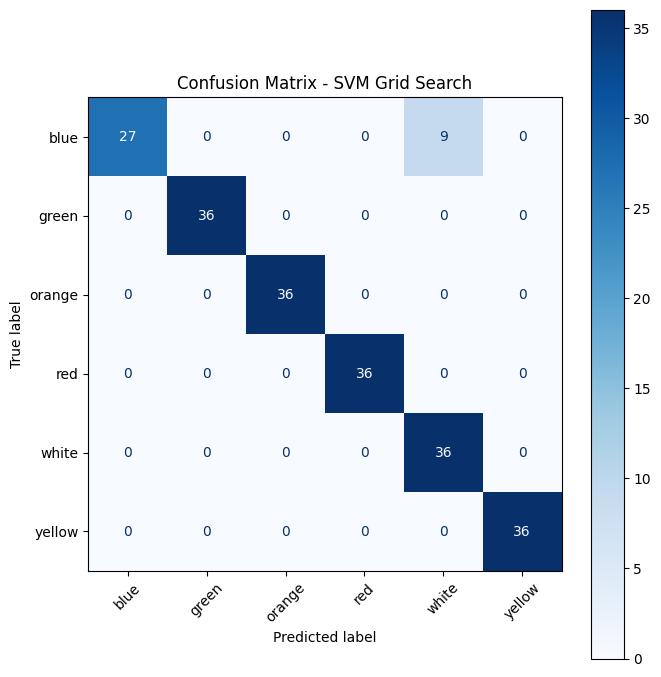

Saved confusion matrix: /content/drive/MyDrive/speedcube-colour-drifting/results/confusion_matrix_svm_grid.png


In [ ]:
import joblib
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.metrics import (
    accuracy_score,
    precision_recall_fscore_support,
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay,
)

# =========================
# Final Test Evaluation
# =========================

test_pred = best_svm_grid.predict(X_test)

test_acc = accuracy_score(y_test, test_pred)

test_precision, test_recall, test_f1, _ = precision_recall_fscore_support(
    y_test,
    test_pred,
    average="macro",
    zero_division=0,
)

print("=== Final Test Evaluation - SVM Grid Search ===")
print("Accuracy        :", test_acc)
print("Precision macro :", test_precision)
print("Recall macro    :", test_recall)
print("F1 macro        :", test_f1)

print("\nClassification report:")
print(classification_report(
    y_test,
    test_pred,
    target_names=label_encoder.classes_,
    zero_division=0,
))

# =========================
# Save model
# =========================

SVM_GRID_MODEL_PATH = MODELS_DIR / "svm_grid_24_features.pkl"
LABEL_ENCODER_PATH = MODELS_DIR / "label_encoder.pkl"

joblib.dump(best_svm_grid, SVM_GRID_MODEL_PATH)
joblib.dump(label_encoder, LABEL_ENCODER_PATH)

print("\nSaved model:", SVM_GRID_MODEL_PATH)
print("Saved label encoder:", LABEL_ENCODER_PATH)

# =========================
# Save result CSV
# =========================

svm_grid_result = {
    "model": "SVM Grid Search",
    "best_params": str(grid_search.best_params_),
    "best_cv_f1_macro": grid_search.best_score_,
    "training_time_seconds": svm_grid_training_time,
    "test_accuracy": test_acc,
    "test_precision_macro": test_precision,
    "test_recall_macro": test_recall,
    "test_f1_macro": test_f1,
}

svm_grid_result_df = pd.DataFrame([svm_grid_result])

SVM_GRID_RESULT_PATH = RESULTS_DIR / "svm_grid_test_result.csv"
svm_grid_result_df.to_csv(SVM_GRID_RESULT_PATH, index=False)

print("Saved result:", SVM_GRID_RESULT_PATH)

# =========================
# Confusion Matrix
# =========================

cm = confusion_matrix(y_test, test_pred)

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=label_encoder.classes_,
)

fig, ax = plt.subplots(figsize=(7, 7))
disp.plot(ax=ax, cmap="Blues", values_format="d")
plt.title("Confusion Matrix - SVM Grid Search")
plt.xticks(rotation=45)
plt.tight_layout()

CM_PATH = RESULTS_DIR / "confusion_matrix_svm_grid.png"
plt.savefig(CM_PATH, dpi=200)
plt.show()

print("Saved confusion matrix:", CM_PATH)

In [ ]:
import cv2
import pandas as pd
import matplotlib.pyplot as plt

# test_pred sudah dari hasil final test SVM Grid
# Kalau belum ada, prediksi ulang:
test_pred = best_svm_grid.predict(X_test)

test_debug_df = test_data.copy()
test_debug_df["true_label"] = label_encoder.inverse_transform(y_test)
test_debug_df["pred_label"] = label_encoder.inverse_transform(test_pred)
test_debug_df["is_correct"] = test_debug_df["true_label"] == test_debug_df["pred_label"]

wrong_df = test_debug_df[test_debug_df["is_correct"] == False].copy()

print("Total wrong predictions:", len(wrong_df))

print("\nWrong prediction pairs:")
print(
    wrong_df.groupby(["true_label", "pred_label"])
    .size()
    .reset_index(name="count")
    .sort_values("count", ascending=False)
)

ERROR_ANALYSIS_PATH = RESULTS_DIR / "svm_grid_wrong_predictions.csv"
wrong_df.to_csv(ERROR_ANALYSIS_PATH, index=False)

print("\nSaved wrong predictions to:", ERROR_ANALYSIS_PATH)

display(wrong_df[["sample_id", "image_id", "true_label", "pred_label", "roi_path"]].head(20))

Total wrong predictions: 9

Wrong prediction pairs:
  true_label pred_label  count
0       blue      white      9

Saved wrong predictions to: /content/drive/MyDrive/speedcube-colour-drifting/results/svm_grid_wrong_predictions.csv


,sample_id,image_id,true_label,pred_label,roi_path
1017,IMG_20260406_121717_r0_c0,blue_IMG_20260406_121717,blue,white,/content/data/roi/blue/IMG_20260406_121717_r0_...
1018,IMG_20260406_121717_r0_c1,blue_IMG_20260406_121717,blue,white,/content/data/roi/blue/IMG_20260406_121717_r0_...
1019,IMG_20260406_121717_r0_c2,blue_IMG_20260406_121717,blue,white,/content/data/roi/blue/IMG_20260406_121717_r0_...
1020,IMG_20260406_121717_r1_c0,blue_IMG_20260406_121717,blue,white,/content/data/roi/blue/IMG_20260406_121717_r1_...
1021,IMG_20260406_121717_r1_c1,blue_IMG_20260406_121717,blue,white,/content/data/roi/blue/IMG_20260406_121717_r1_...
1022,IMG_20260406_121717_r1_c2,blue_IMG_20260406_121717,blue,white,/content/data/roi/blue/IMG_20260406_121717_r1_...
1023,IMG_20260406_121717_r2_c0,blue_IMG_20260406_121717,blue,white,/content/data/roi/blue/IMG_20260406_121717_r2_...
1024,IMG_20260406_121717_r2_c1,blue_IMG_20260406_121717,blue,white,/content/data/roi/blue/IMG_20260406_121717_r2_...
1025,IMG_20260406_121717_r2_c2,blue_IMG_20260406_121717,blue,white,/content/data/roi/blue/IMG_20260406_121717_r2_...


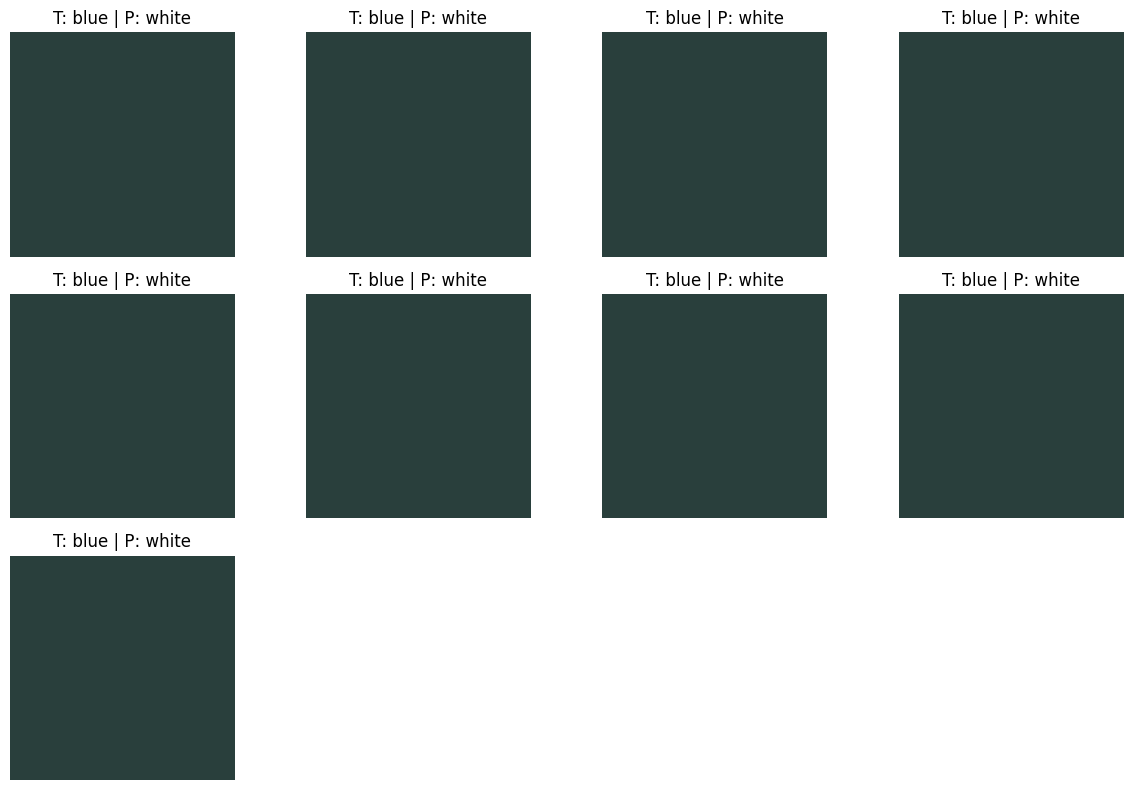

Saved figure to: /content/drive/MyDrive/speedcube-colour-drifting/results/svm_grid_wrong_prediction_examples.png


In [ ]:
max_images = min(12, len(wrong_df))

if max_images == 0:
    print("No wrong predictions.")
else:
    plt.figure(figsize=(12, 8))

    for i, (_, row) in enumerate(wrong_df.head(max_images).iterrows()):
        img = cv2.imread(row["roi_path"])
        img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

        plt.subplot(3, 4, i + 1)
        plt.imshow(img)
        plt.title(f"T: {row['true_label']} | P: {row['pred_label']}")
        plt.axis("off")

    plt.tight_layout()

    ERROR_FIG_PATH = RESULTS_DIR / "svm_grid_wrong_prediction_examples.png"
    plt.savefig(ERROR_FIG_PATH, dpi=200)
    plt.show()

    print("Saved figure to:", ERROR_FIG_PATH)

# SVM PSO

In [ ]:
import time
import joblib
import numpy as np
import pandas as pd

from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.svm import SVC
from sklearn.metrics import (
    f1_score,
    accuracy_score,
    precision_recall_fscore_support,
    classification_report,
)

PSO_CONFIG = {
    "n_particles": 10,
    "n_iterations": 15,

    "w": 0.72,
    "c1": 1.49,
    "c2": 1.49,

    # C = 10 ** log_C
    "log_C_min": -2,   # 0.01
    "log_C_max": 3,    # 1000

    # gamma = 10 ** log_gamma
    "log_gamma_min": -5,  # 0.00001
    "log_gamma_max": 0,   # 1
}

rng = np.random.default_rng(RANDOM_STATE)

print("PSO config:")
PSO_CONFIG

PSO config:


{'n_particles': 10,
 'n_iterations': 15,
 'w': 0.72,
 'c1': 1.49,
 'c2': 1.49,
 'log_C_min': -2,
 'log_C_max': 3,
 'log_gamma_min': -5,
 'log_gamma_max': 0}

In [ ]:
def decode_particle(position):
    """
    Convert particle position in log-space into actual SVM parameters.

    position = [log_C, log_gamma]
    """
    log_C, log_gamma = position

    C = 10 ** log_C
    gamma = 10 ** log_gamma

    return C, gamma


def build_svm_model(C, gamma, probability=False):
    """
    Build SVM pipeline.

    StandardScaler ada di dalam pipeline supaya scaling fit hanya pada train data.
    """
    return Pipeline([
        ("scaler", StandardScaler()),
        ("svm", SVC(
            kernel="rbf",
            C=C,
            gamma=gamma,
            probability=probability,
            random_state=RANDOM_STATE,
        )),
    ])


def evaluate_svm_candidate_cv(position, n_splits=3):
    """
    Fitness PSO berbasis GroupKFold pada train set.

    Ini lebih aman daripada memakai validation langsung,
    karena validation tidak ikut proses tuning.
    """
    C, gamma = decode_particle(position)

    groups = train_data["image_id"].values
    cv = GroupKFold(n_splits=n_splits)

    fold_scores = []

    for train_idx, cv_idx in cv.split(X_train, y_train, groups=groups):
        X_fold_train = X_train[train_idx]
        y_fold_train = y_train[train_idx]

        X_fold_val = X_train[cv_idx]
        y_fold_val = y_train[cv_idx]

        model = build_svm_model(
            C=C,
            gamma=gamma,
            probability=False,
        )

        model.fit(X_fold_train, y_fold_train)
        pred = model.predict(X_fold_val)

        fold_f1 = f1_score(
            y_fold_val,
            pred,
            average="macro",
            zero_division=0,
        )

        fold_scores.append(fold_f1)

    return float(np.mean(fold_scores))

In [ ]:
n_particles = PSO_CONFIG["n_particles"]
n_iterations = PSO_CONFIG["n_iterations"]

lower_bounds = np.array([
    PSO_CONFIG["log_C_min"],
    PSO_CONFIG["log_gamma_min"],
])

upper_bounds = np.array([
    PSO_CONFIG["log_C_max"],
    PSO_CONFIG["log_gamma_max"],
])

positions = rng.uniform(
    low=lower_bounds,
    high=upper_bounds,
    size=(n_particles, 2),
)

velocities = rng.uniform(
    low=-0.1,
    high=0.1,
    size=(n_particles, 2),
)

personal_best_positions = positions.copy()
personal_best_scores = np.full(n_particles, -np.inf)

global_best_position = None
global_best_score = -np.inf

pso_history = []

start_time = time.time()

for iteration in range(n_iterations):
    iteration_scores = []

    for i in range(n_particles):
        score = evaluate_svm_candidate_cv(positions[i], n_splits=3)
        iteration_scores.append(score)

        if score > personal_best_scores[i]:
            personal_best_scores[i] = score
            personal_best_positions[i] = positions[i].copy()

        if score > global_best_score:
            global_best_score = score
            global_best_position = positions[i].copy()

    r1 = rng.random(size=(n_particles, 2))
    r2 = rng.random(size=(n_particles, 2))

    velocities = (
        PSO_CONFIG["w"] * velocities
        + PSO_CONFIG["c1"] * r1 * (personal_best_positions - positions)
        + PSO_CONFIG["c2"] * r2 * (global_best_position - positions)
    )

    positions = positions + velocities
    positions = np.clip(positions, lower_bounds, upper_bounds)

    best_C, best_gamma = decode_particle(global_best_position)

    pso_history.append({
        "iteration": iteration + 1,
        "best_val_f1_macro": global_best_score,
        "best_C": best_C,
        "best_gamma": best_gamma,
        "mean_particle_score": float(np.mean(iteration_scores)),
        "max_particle_score": float(np.max(iteration_scores)),
    })

    print(
        f"Iter {iteration + 1:02d}/{n_iterations} | "
        f"Best F1: {global_best_score:.5f} | "
        f"C: {best_C:.6f} | "
        f"gamma: {best_gamma:.8f}"
    )

svm_pso_tuning_time = time.time() - start_time

best_C, best_gamma = decode_particle(global_best_position)

print("\n=== Best PSO Result ===")
print("Best validation F1 macro:", global_best_score)
print("Best C:", best_C)
print("Best gamma:", best_gamma)
print("PSO tuning time:", svm_pso_tuning_time, "seconds")

Iter 01/15 | Best F1: 0.95169 | C: 49.791744 | gamma: 0.10100851
Iter 02/15 | Best F1: 0.95553 | C: 36.314015 | gamma: 0.00743560
Iter 03/15 | Best F1: 0.95760 | C: 34.285584 | gamma: 0.02284415
Iter 04/15 | Best F1: 0.95760 | C: 34.285584 | gamma: 0.02284415
Iter 05/15 | Best F1: 0.95760 | C: 34.285584 | gamma: 0.02284415
Iter 06/15 | Best F1: 0.95760 | C: 34.285584 | gamma: 0.02284415
Iter 07/15 | Best F1: 0.95760 | C: 34.285584 | gamma: 0.02284415
Iter 08/15 | Best F1: 0.95849 | C: 52.331477 | gamma: 0.01795042
Iter 09/15 | Best F1: 0.95849 | C: 52.331477 | gamma: 0.01795042
Iter 10/15 | Best F1: 0.95849 | C: 52.331477 | gamma: 0.01795042
Iter 11/15 | Best F1: 0.95849 | C: 52.331477 | gamma: 0.01795042
Iter 12/15 | Best F1: 0.95849 | C: 52.331477 | gamma: 0.01795042
Iter 13/15 | Best F1: 0.95849 | C: 52.331477 | gamma: 0.01795042
Iter 14/15 | Best F1: 0.95849 | C: 52.331477 | gamma: 0.01795042
Iter 15/15 | Best F1: 0.95849 | C: 52.331477 | gamma: 0.01795042

=== Best PSO Result ===


In [ ]:
best_svm_pso = build_svm_model(
    C=best_C,
    gamma=best_gamma,
    probability=True,
)

best_svm_pso.fit(X_train, y_train)

val_pred_pso = best_svm_pso.predict(X_val)

val_acc = accuracy_score(y_val, val_pred_pso)
val_precision, val_recall, val_f1, _ = precision_recall_fscore_support(
    y_val,
    val_pred_pso,
    average="macro",
    zero_division=0,
)

print("=== Validation Evaluation - SVM PSO ===")
print("Accuracy        :", val_acc)
print("Precision macro :", val_precision)
print("Recall macro    :", val_recall)
print("F1 macro        :", val_f1)

print("\nValidation classification report:")
print(classification_report(
    y_val,
    val_pred_pso,
    target_names=label_encoder.classes_,
    zero_division=0,
))

=== Validation Evaluation - SVM PSO ===
Accuracy        : 0.9907407407407407
Precision macro : 0.990990990990991
Recall macro    : 0.9907407407407408
F1 macro        : 0.9907389542735867

Validation classification report:
              precision    recall  f1-score   support

        blue       0.97      1.00      0.99        36
       green       1.00      0.97      0.99        36
      orange       1.00      1.00      1.00        36
         red       1.00      1.00      1.00        36
       white       1.00      0.97      0.99        36
      yellow       0.97      1.00      0.99        36

    accuracy                           0.99       216
   macro avg       0.99      0.99      0.99       216
weighted avg       0.99      0.99      0.99       216



In [ ]:
test_pred_pso = best_svm_pso.predict(X_test)

test_acc = accuracy_score(y_test, test_pred_pso)
test_precision, test_recall, test_f1, _ = precision_recall_fscore_support(
    y_test,
    test_pred_pso,
    average="macro",
    zero_division=0,
)

print("=== Final Test Evaluation - SVM PSO ===")
print("Accuracy        :", test_acc)
print("Precision macro :", test_precision)
print("Recall macro    :", test_recall)
print("F1 macro        :", test_f1)

print("\nTest classification report:")
print(classification_report(
    y_test,
    test_pred_pso,
    target_names=label_encoder.classes_,
    zero_division=0,
))

=== Final Test Evaluation - SVM PSO ===
Accuracy        : 0.9583333333333334
Precision macro : 0.9666666666666667
Recall macro    : 0.9583333333333334
F1 macro        : 0.9576719576719577

Test classification report:
              precision    recall  f1-score   support

        blue       1.00      0.75      0.86        36
       green       1.00      1.00      1.00        36
      orange       1.00      1.00      1.00        36
         red       1.00      1.00      1.00        36
       white       0.80      1.00      0.89        36
      yellow       1.00      1.00      1.00        36

    accuracy                           0.96       216
   macro avg       0.97      0.96      0.96       216
weighted avg       0.97      0.96      0.96       216



In [ ]:
svm_pso_result = {
    "model": "SVM PSO",
    "best_C": best_C,
    "best_gamma": best_gamma,
    "best_validation_f1_macro": val_f1,
    "tuning_cv_f1_macro": global_best_score,
    "tuning_time_seconds": svm_pso_tuning_time,
    "test_accuracy": test_acc,
    "test_precision_macro": test_precision,
    "test_recall_macro": test_recall,
    "test_f1_macro": test_f1,
}

SVM_PSO_RESULT_PATH = RESULTS_DIR / "svm_pso_test_result.csv"

pd.DataFrame([svm_pso_result]).to_csv(SVM_PSO_RESULT_PATH, index=False)

print("Saved test result:", SVM_PSO_RESULT_PATH)

Saved test result: /content/drive/MyDrive/speedcube-colour-drifting/results/svm_pso_test_result.csv


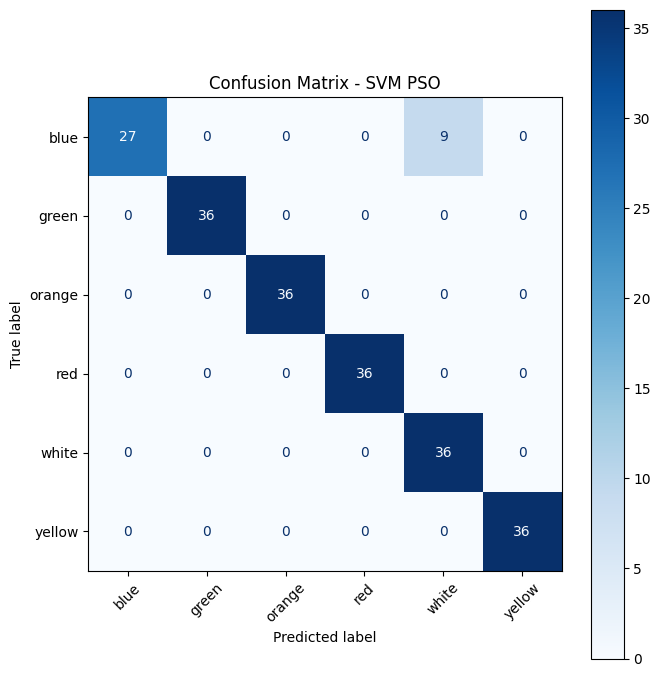

Saved confusion matrix: /content/drive/MyDrive/speedcube-colour-drifting/results/confusion_matrix_svm_pso.png


In [ ]:
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

cm_pso = confusion_matrix(y_test, test_pred_pso)

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm_pso,
    display_labels=label_encoder.classes_,
)

fig, ax = plt.subplots(figsize=(7, 7))
disp.plot(ax=ax, cmap="Blues", values_format="d")

plt.title("Confusion Matrix - SVM PSO")
plt.xticks(rotation=45)
plt.tight_layout()

SVM_PSO_CM_PATH = RESULTS_DIR / "confusion_matrix_svm_pso.png"
plt.savefig(SVM_PSO_CM_PATH, dpi=200)
plt.show()

print("Saved confusion matrix:", SVM_PSO_CM_PATH)

In [ ]:

BASE_DIR = Path("/content/drive/MyDrive/speedcube-colour-drifting")

PROCESSED_DIR = BASE_DIR / "processed"
MODELS_DIR = BASE_DIR / "models"
RESULTS_DIR = BASE_DIR / "results"

MODELS_DIR.mkdir(parents=True, exist_ok=True)
RESULTS_DIR.mkdir(parents=True, exist_ok=True)

FEATURES_PATH = PROCESSED_DIR / "features_24.csv"
LABEL_ENCODER_PATH = MODELS_DIR / "label_encoder.pkl"

SVM_PSO_MODEL_PATH = MODELS_DIR / "svm_pso_24_features.pkl"
SVM_PSO_PARAMS_PATH = RESULTS_DIR / "svm_pso_best_params.json"

print("Features path:", FEATURES_PATH)
print("Models dir   :", MODELS_DIR)

BEST_PSO_C = 52.33147668239887
BEST_PSO_GAMMA = 0.017950424212579686

svm_pso_model = Pipeline([
    ("scaler", StandardScaler()),
    ("svm", SVC(
        kernel="rbf",
        C=BEST_PSO_C,
        gamma=BEST_PSO_GAMMA,
        probability=True,
        random_state=42,
    )),
])

svm_pso_model.fit(X_train, y_train)

print("SVM PSO model trained.")


# =========================
# Save model and params
# =========================

joblib.dump(svm_pso_model, SVM_PSO_MODEL_PATH)

svm_pso_params = {
    "model": "SVM PSO",
    "input": "24 color features",
    "kernel": "rbf",
    "C": BEST_PSO_C,
    "gamma": BEST_PSO_GAMMA,
    "probability": True,
    "random_state": 42,
    "feature_columns": FEATURE_COLUMNS,
    "classes": list(label_encoder.classes_),
}

with open(SVM_PSO_PARAMS_PATH, "w") as f:
    json.dump(svm_pso_params, f, indent=4)

print("Saved SVM PSO model :", SVM_PSO_MODEL_PATH)
print("Saved SVM PSO params:", SVM_PSO_PARAMS_PATH)

Features path: /content/drive/MyDrive/speedcube-colour-drifting/processed/features_24.csv
Models dir   : /content/drive/MyDrive/speedcube-colour-drifting/models
SVM PSO model trained.
Saved SVM PSO model : /content/drive/MyDrive/speedcube-colour-drifting/models/svm_pso_24_features.pkl
Saved SVM PSO params: /content/drive/MyDrive/speedcube-colour-drifting/results/svm_pso_best_params.json


In [ ]:
print("Grid Search best params:")
print(grid_search.best_params_)

print("\nPSO best params:")
print("C:", best_C)
print("gamma:", best_gamma)

grid_pred = best_svm_grid.predict(X_test)
pso_pred = best_svm_pso.predict(X_test)

print("\nPredictions exactly same:")
print((grid_pred == pso_pred).all())

print("\nNumber of different predictions:")
print((grid_pred != pso_pred).sum())

Grid Search best params:
{'svm__C': 10, 'svm__gamma': 'scale', 'svm__kernel': 'rbf'}

PSO best params:
C: 52.33147668239887
gamma: 0.017950424212579686

Predictions exactly same:
True

Number of different predictions:
0


# MLP

In [ ]:
import random
import numpy as np
import pandas as pd
import torch

from pathlib import Path
from sklearn.preprocessing import StandardScaler, LabelEncoder
from torch.utils.data import Dataset, DataLoader

# =========================
# Reproducibility
# =========================

def set_seed(seed=42):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)

    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False


set_seed(RANDOM_STATE)


# =========================
# Device
# =========================

if torch.cuda.is_available():
    DEVICE = torch.device("cuda")
elif hasattr(torch.backends, "mps") and torch.backends.mps.is_available():
    DEVICE = torch.device("mps")
else:
    DEVICE = torch.device("cpu")

print("Device:", DEVICE)


# =========================
# Load features
# =========================

try:
    features_df
except NameError:
    FEATURES_PATH = PROCESSED_DIR / "features_24.csv"
    features_df = pd.read_csv(FEATURES_PATH)

print("Features shape:", features_df.shape)
print(pd.crosstab(features_df["label"], features_df["split"]))


# =========================
# Split data
# =========================

train_data = features_df[features_df["split"] == "train"].copy()
val_data = features_df[features_df["split"] == "val"].copy()
test_data = features_df[features_df["split"] == "test"].copy()

X_train = train_data[FEATURE_COLUMNS].values
X_val = val_data[FEATURE_COLUMNS].values
X_test = test_data[FEATURE_COLUMNS].values

label_encoder = LabelEncoder()
label_encoder.fit(train_data["label"])

y_train = label_encoder.transform(train_data["label"])
y_val = label_encoder.transform(val_data["label"])
y_test = label_encoder.transform(test_data["label"])

print("Classes:", list(label_encoder.classes_))


# =========================
# StandardScaler: fit train only
# =========================

mlp_scaler = StandardScaler()

X_train_scaled = mlp_scaler.fit_transform(X_train)
X_val_scaled = mlp_scaler.transform(X_val)
X_test_scaled = mlp_scaler.transform(X_test)

print("X_train_scaled:", X_train_scaled.shape)
print("X_val_scaled:", X_val_scaled.shape)
print("X_test_scaled:", X_test_scaled.shape)


# =========================
# Dataset
# =========================

class ColorFeatureDataset(Dataset):
    def __init__(self, X, y):
        self.X = torch.tensor(X, dtype=torch.float32)
        self.y = torch.tensor(y, dtype=torch.long)

    def __len__(self):
        return len(self.X)

    def __getitem__(self, idx):
        return self.X[idx], self.y[idx]


# =========================
# DataLoader
# =========================

BATCH_SIZE = 32

train_dataset = ColorFeatureDataset(X_train_scaled, y_train)
val_dataset = ColorFeatureDataset(X_val_scaled, y_val)
test_dataset = ColorFeatureDataset(X_test_scaled, y_test)

train_loader = DataLoader(
    train_dataset,
    batch_size=BATCH_SIZE,
    shuffle=True,
)

val_loader = DataLoader(
    val_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False,
)

test_loader = DataLoader(
    test_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False,
)

print("Train batches:", len(train_loader))
print("Val batches:", len(val_loader))
print("Test batches:", len(test_loader))

Device: cuda
Features shape: (5022, 31)
split   test  train  val
label                   
blue      36    765   36
green     36    765   36
orange    36    765   36
red       36    765   36
white     36    765   36
yellow    36    765   36
Classes: ['blue', 'green', 'orange', 'red', 'white', 'yellow']
X_train_scaled: (4590, 24)
X_val_scaled: (216, 24)
X_test_scaled: (216, 24)
Train batches: 144
Val batches: 7
Test batches: 7


In [ ]:
import torch
import torch.nn as nn

# =========================
# MLP Model
# =========================

class MLPColorClassifier(nn.Module):
    def __init__(self, input_dim=24, num_classes=6, dropout=0.2):
        super().__init__()

        self.net = nn.Sequential(
            nn.Linear(input_dim, 64),
            nn.BatchNorm1d(64),
            nn.ReLU(),
            nn.Dropout(dropout),

            nn.Linear(64, 32),
            nn.BatchNorm1d(32),
            nn.ReLU(),
            nn.Dropout(dropout),

            nn.Linear(32, num_classes)
        )

    def forward(self, x):
        return self.net(x)


# =========================
# Model Config
# =========================

INPUT_DIM = len(FEATURE_COLUMNS)
NUM_CLASSES = len(label_encoder.classes_)

DROPOUT = 0.2
LEARNING_RATE = 1e-3
WEIGHT_DECAY = 1e-4

model_mlp = MLPColorClassifier(
    input_dim=INPUT_DIM,
    num_classes=NUM_CLASSES,
    dropout=DROPOUT,
).to(DEVICE)

criterion = nn.CrossEntropyLoss()

optimizer = torch.optim.Adam(
    model_mlp.parameters(),
    lr=LEARNING_RATE,
    weight_decay=WEIGHT_DECAY,
)

print(model_mlp)
print("Input dim:", INPUT_DIM)
print("Num classes:", NUM_CLASSES)
print("Device:", DEVICE)

MLPColorClassifier(
  (net): Sequential(
    (0): Linear(in_features=24, out_features=64, bias=True)
    (1): BatchNorm1d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (2): ReLU()
    (3): Dropout(p=0.2, inplace=False)
    (4): Linear(in_features=64, out_features=32, bias=True)
    (5): BatchNorm1d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (6): ReLU()
    (7): Dropout(p=0.2, inplace=False)
    (8): Linear(in_features=32, out_features=6, bias=True)
  )
)
Input dim: 24
Num classes: 6
Device: cuda


In [ ]:
from tqdm.auto import tqdm
from sklearn.metrics import accuracy_score, precision_recall_fscore_support, classification_report
import numpy as np
import torch


def train_one_epoch_mlp(
    model,
    dataloader,
    criterion,
    optimizer,
    device,
    grad_clip=1.0,
):
    model.train()

    total_loss = 0.0
    all_preds = []
    all_targets = []

    progress_bar = tqdm(dataloader, desc="Training", leave=False)

    for X_batch, y_batch in progress_bar:
        X_batch = X_batch.to(device)
        y_batch = y_batch.to(device)

        optimizer.zero_grad(set_to_none=True)

        logits = model(X_batch)
        loss = criterion(logits, y_batch)

        loss.backward()

        if grad_clip is not None:
            torch.nn.utils.clip_grad_norm_(
                model.parameters(),
                max_norm=grad_clip,
            )

        optimizer.step()

        batch_size = X_batch.size(0)
        total_loss += loss.item() * batch_size

        preds = torch.argmax(logits, dim=1)

        all_preds.extend(preds.detach().cpu().numpy())
        all_targets.extend(y_batch.detach().cpu().numpy())

        progress_bar.set_postfix(loss=loss.item())

    avg_loss = total_loss / len(dataloader.dataset)

    accuracy = accuracy_score(all_targets, all_preds)
    precision, recall, f1, _ = precision_recall_fscore_support(
        all_targets,
        all_preds,
        average="macro",
        zero_division=0,
    )

    return {
        "loss": avg_loss,
        "accuracy": accuracy,
        "precision_macro": precision,
        "recall_macro": recall,
        "f1_macro": f1,
    }


@torch.no_grad()
def evaluate_mlp(
    model,
    dataloader,
    criterion,
    device,
):
    model.eval()

    total_loss = 0.0
    all_preds = []
    all_targets = []

    for X_batch, y_batch in dataloader:
        X_batch = X_batch.to(device)
        y_batch = y_batch.to(device)

        logits = model(X_batch)
        loss = criterion(logits, y_batch)

        batch_size = X_batch.size(0)
        total_loss += loss.item() * batch_size

        preds = torch.argmax(logits, dim=1)

        all_preds.extend(preds.detach().cpu().numpy())
        all_targets.extend(y_batch.detach().cpu().numpy())

    avg_loss = total_loss / len(dataloader.dataset)

    accuracy = accuracy_score(all_targets, all_preds)
    precision, recall, f1, _ = precision_recall_fscore_support(
        all_targets,
        all_preds,
        average="macro",
        zero_division=0,
    )

    return {
        "loss": avg_loss,
        "accuracy": accuracy,
        "precision_macro": precision,
        "recall_macro": recall,
        "f1_macro": f1,
        "y_true": np.array(all_targets),
        "y_pred": np.array(all_preds),
    }

In [ ]:
import copy
import time
import pandas as pd

# =========================
# Training Config
# =========================

MAX_EPOCHS = 100
PATIENCE = 15
MIN_DELTA = 1e-4

best_val_f1 = -1.0
best_epoch = -1
epochs_without_improvement = 0

best_model_state = None
mlp_history = []

start_time = time.time()

# =========================
# Training Loop
# =========================

for epoch in range(1, MAX_EPOCHS + 1):
    train_metrics = train_one_epoch_mlp(
        model=model_mlp,
        dataloader=train_loader,
        criterion=criterion,
        optimizer=optimizer,
        device=DEVICE,
        grad_clip=1.0,
    )

    val_metrics = evaluate_mlp(
        model=model_mlp,
        dataloader=val_loader,
        criterion=criterion,
        device=DEVICE,
    )

    current_val_f1 = val_metrics["f1_macro"]

    mlp_history.append({
        "epoch": epoch,

        "train_loss": train_metrics["loss"],
        "train_accuracy": train_metrics["accuracy"],
        "train_precision_macro": train_metrics["precision_macro"],
        "train_recall_macro": train_metrics["recall_macro"],
        "train_f1_macro": train_metrics["f1_macro"],

        "val_loss": val_metrics["loss"],
        "val_accuracy": val_metrics["accuracy"],
        "val_precision_macro": val_metrics["precision_macro"],
        "val_recall_macro": val_metrics["recall_macro"],
        "val_f1_macro": val_metrics["f1_macro"],
    })

    improved = current_val_f1 > best_val_f1 + MIN_DELTA

    if improved:
        best_val_f1 = current_val_f1
        best_epoch = epoch
        epochs_without_improvement = 0
        best_model_state = copy.deepcopy(model_mlp.state_dict())
    else:
        epochs_without_improvement += 1

    print(
        f"Epoch {epoch:03d} | "
        f"Train Loss: {train_metrics['loss']:.4f} | "
        f"Train F1: {train_metrics['f1_macro']:.4f} | "
        f"Val Loss: {val_metrics['loss']:.4f} | "
        f"Val F1: {val_metrics['f1_macro']:.4f} | "
        f"Best Val F1: {best_val_f1:.4f}"
    )

    if epochs_without_improvement >= PATIENCE:
        print(f"\nEarly stopping at epoch {epoch}.")
        break


mlp_training_time = time.time() - start_time

# =========================
# Restore Best Model
# =========================

model_mlp.load_state_dict(best_model_state)

print("\n=== MLP Training Finished ===")
print("Best epoch:", best_epoch)
print("Best validation F1 macro:", best_val_f1)
print("Training time:", mlp_training_time, "seconds")

Training:   0%|          | 0/144 [00:00<?, ?it/s]

Epoch 001 | Train Loss: 0.2078 | Train F1: 0.9290 | Val Loss: 0.0487 | Val F1: 0.9907 | Best Val F1: 0.9907


Training:   0%|          | 0/144 [00:00<?, ?it/s]

Epoch 002 | Train Loss: 0.1705 | Train F1: 0.9388 | Val Loss: 0.0306 | Val F1: 0.9954 | Best Val F1: 0.9954


Training:   0%|          | 0/144 [00:00<?, ?it/s]

...

Epoch 016 | Train Loss: 0.1130 | Train F1: 0.9566 | Val Loss: 0.0148 | Val F1: 1.0000 | Best Val F1: 1.0000


Training:   0%|          | 0/144 [00:00<?, ?it/s]

Epoch 017 | Train Loss: 0.1195 | Train F1: 0.9541 | Val Loss: 0.0112 | Val F1: 1.0000 | Best Val F1: 1.0000


Training:   0%|          | 0/144 [00:00<?, ?it/s]

Epoch 018 | Train Loss: 0.1119 | Train F1: 0.9562 | Val Loss: 0.0155 | Val F1: 0.9954 | Best Val F1: 1.0000

Early stopping at epoch 18.

=== MLP Training Finished ===
Best epoch: 3
Best validation F1 macro: 1.0
Training time: 14.930450439453125 seconds


In [ ]:
val_metrics_mlp = evaluate_mlp(
    model=model_mlp,
    dataloader=val_loader,
    criterion=criterion,
    device=DEVICE,
)

print("=== Validation Evaluation - MLP ===")
print("Loss            :", val_metrics_mlp["loss"])
print("Accuracy        :", val_metrics_mlp["accuracy"])
print("Precision macro :", val_metrics_mlp["precision_macro"])
print("Recall macro    :", val_metrics_mlp["recall_macro"])
print("F1 macro        :", val_metrics_mlp["f1_macro"])

print("\nValidation classification report:")
print(classification_report(
    val_metrics_mlp["y_true"],
    val_metrics_mlp["y_pred"],
    target_names=label_encoder.classes_,
    zero_division=0,
))

=== Validation Evaluation - MLP ===
Loss            : 0.027948999777436256
Accuracy        : 1.0
Precision macro : 1.0
Recall macro    : 1.0
F1 macro        : 1.0

Validation classification report:
              precision    recall  f1-score   support

        blue       1.00      1.00      1.00        36
       green       1.00      1.00      1.00        36
      orange       1.00      1.00      1.00        36
         red       1.00      1.00      1.00        36
       white       1.00      1.00      1.00        36
      yellow       1.00      1.00      1.00        36

    accuracy                           1.00       216
   macro avg       1.00      1.00      1.00       216
weighted avg       1.00      1.00      1.00       216



In [ ]:
mlp_history_df = pd.DataFrame(mlp_history)

MLP_HISTORY_PATH = RESULTS_DIR / "mlp_history.csv"
MLP_MODEL_PATH = MODELS_DIR / "mlp_24_features.pt"
MLP_SCALER_PATH = MODELS_DIR / "mlp_scaler.pkl"

mlp_history_df.to_csv(MLP_HISTORY_PATH, index=False)

torch.save({
    "model_state_dict": model_mlp.state_dict(),
    "input_dim": INPUT_DIM,
    "num_classes": NUM_CLASSES,
    "dropout": DROPOUT,
    "classes": list(label_encoder.classes_),
    "feature_columns": FEATURE_COLUMNS,
}, MLP_MODEL_PATH)

joblib.dump(mlp_scaler, MLP_SCALER_PATH)

print("Saved MLP history:", MLP_HISTORY_PATH)
print("Saved MLP model:", MLP_MODEL_PATH)
print("Saved MLP scaler:", MLP_SCALER_PATH)

Saved MLP history: /content/drive/MyDrive/speedcube-colour-drifting/results/mlp_history.csv
Saved MLP model: /content/drive/MyDrive/speedcube-colour-drifting/models/mlp_24_features.pt
Saved MLP scaler: /content/drive/MyDrive/speedcube-colour-drifting/models/mlp_scaler.pkl


In [ ]:
test_metrics_mlp = evaluate_mlp(
    model=model_mlp,
    dataloader=test_loader,
    criterion=criterion,
    device=DEVICE,
)

print("=== Final Test Evaluation - MLP ===")
print("Loss            :", test_metrics_mlp["loss"])
print("Accuracy        :", test_metrics_mlp["accuracy"])
print("Precision macro :", test_metrics_mlp["precision_macro"])
print("Recall macro    :", test_metrics_mlp["recall_macro"])
print("F1 macro        :", test_metrics_mlp["f1_macro"])

print("\nTest classification report:")
print(classification_report(
    test_metrics_mlp["y_true"],
    test_metrics_mlp["y_pred"],
    target_names=label_encoder.classes_,
    zero_division=0,
))

=== Final Test Evaluation - MLP ===
Loss            : 0.181821018802347
Accuracy        : 0.9537037037037037
Precision macro : 0.9621621621621621
Recall macro    : 0.9537037037037037
F1 macro        : 0.953041434808751

Test classification report:
              precision    recall  f1-score   support

        blue       1.00      0.75      0.86        36
       green       1.00      1.00      1.00        36
      orange       0.97      1.00      0.99        36
         red       1.00      0.97      0.99        36
       white       0.80      1.00      0.89        36
      yellow       1.00      1.00      1.00        36

    accuracy                           0.95       216
   macro avg       0.96      0.95      0.95       216
weighted avg       0.96      0.95      0.95       216



NameError: name 'effnet_mlp_test_metrics' is not defined

# MobileNetV2


In [ ]:
import torch
import torch.nn as nn
from torchvision.models import mobilenet_v2, MobileNet_V2_Weights

# =========================
# Device
# =========================

if torch.cuda.is_available():
    DEVICE = torch.device("cuda")
elif hasattr(torch.backends, "mps") and torch.backends.mps.is_available():
    DEVICE = torch.device("mps")
else:
    DEVICE = torch.device("cpu")

print("Device:", DEVICE)


# =========================
# Load Pretrained MobileNetV2
# =========================

weights = MobileNet_V2_Weights.DEFAULT
mobilenet_preprocess = weights.transforms()

mobilenet = mobilenet_v2(weights=weights)

# Ambil bagian feature extractor saja, buang classifier
mobilenet_feature_extractor = nn.Sequential(
    mobilenet.features,
    nn.AdaptiveAvgPool2d((1, 1)),
    nn.Flatten()
).to(DEVICE)

mobilenet_feature_extractor.eval()

# Freeze semua parameter
for param in mobilenet_feature_extractor.parameters():
    param.requires_grad = False

print("MobileNetV2 feature extractor ready.")
print("Output feature dimension: 1280")

Device: cuda
Downloading: "https://download.pytorch.org/models/mobilenet_v2-7ebf99e0.pth" to /root/.cache/torch/hub/checkpoints/mobilenet_v2-7ebf99e0.pth


100%|██████████| 13.6M/13.6M [00:00<00:00, 102MB/s] 


MobileNetV2 feature extractor ready.
Output feature dimension: 1280


In [ ]:
from PIL import Image
from torch.utils.data import Dataset, DataLoader
import os

# =========================
# Split metadata
# =========================

mobilenet_train_data = features_df[features_df["split"] == "train"].copy()
mobilenet_val_data = features_df[features_df["split"] == "val"].copy()
mobilenet_test_data = features_df[features_df["split"] == "test"].copy()

print("Train:", mobilenet_train_data.shape)
print("Val  :", mobilenet_val_data.shape)
print("Test :", mobilenet_test_data.shape)


# =========================
# Check image paths
# =========================

missing_paths = []

for path in features_df["roi_path"].values:
    if not os.path.exists(path):
        missing_paths.append(path)

print("Missing image paths:", len(missing_paths))

if len(missing_paths) > 0:
    print("Example missing path:")
    print(missing_paths[0])


# =========================
# Dataset
# =========================

class MobileNetROIDataset(Dataset):
    def __init__(self, dataframe, label_encoder, transform):
        self.dataframe = dataframe.reset_index(drop=True)
        self.label_encoder = label_encoder
        self.transform = transform

        self.paths = self.dataframe["roi_path"].values
        self.labels = self.label_encoder.transform(self.dataframe["label"].values)

    def __len__(self):
        return len(self.dataframe)

    def __getitem__(self, idx):
        image_path = self.paths[idx]

        image = Image.open(image_path).convert("RGB")
        image = self.transform(image)

        label = int(self.labels[idx])

        return image, label


# =========================
# DataLoader
# =========================

MOBILENET_BATCH_SIZE = 64

mobilenet_train_dataset = MobileNetROIDataset(
    dataframe=mobilenet_train_data,
    label_encoder=label_encoder,
    transform=mobilenet_preprocess,
)

mobilenet_val_dataset = MobileNetROIDataset(
    dataframe=mobilenet_val_data,
    label_encoder=label_encoder,
    transform=mobilenet_preprocess,
)

mobilenet_test_dataset = MobileNetROIDataset(
    dataframe=mobilenet_test_data,
    label_encoder=label_encoder,
    transform=mobilenet_preprocess,
)

mobilenet_train_loader = DataLoader(
    mobilenet_train_dataset,
    batch_size=MOBILENET_BATCH_SIZE,
    shuffle=False,
    num_workers=2,
)

mobilenet_val_loader = DataLoader(
    mobilenet_val_dataset,
    batch_size=MOBILENET_BATCH_SIZE,
    shuffle=False,
    num_workers=2,
)

mobilenet_test_loader = DataLoader(
    mobilenet_test_dataset,
    batch_size=MOBILENET_BATCH_SIZE,
    shuffle=False,
    num_workers=2,
)

print("Train batches:", len(mobilenet_train_loader))
print("Val batches  :", len(mobilenet_val_loader))
print("Test batches :", len(mobilenet_test_loader))

Train: (4590, 31)
Val  : (216, 31)
Test : (216, 31)
Missing image paths: 0
Train batches: 72
Val batches  : 4
Test batches : 4


In [ ]:
from tqdm.auto import tqdm
import numpy as np
import torch

@torch.no_grad()
def extract_mobilenet_features(feature_extractor, dataloader, device):
    feature_extractor.eval()

    all_features = []
    all_labels = []

    for images, labels in tqdm(dataloader, desc="Extracting MobileNetV2 features"):
        images = images.to(device)

        features = feature_extractor(images)

        all_features.append(features.cpu().numpy())
        all_labels.append(labels.numpy())

    all_features = np.concatenate(all_features, axis=0)
    all_labels = np.concatenate(all_labels, axis=0)

    return all_features, all_labels


X_train_mobilenet, y_train_mobilenet = extract_mobilenet_features(
    mobilenet_feature_extractor,
    mobilenet_train_loader,
    DEVICE,
)

X_val_mobilenet, y_val_mobilenet = extract_mobilenet_features(
    mobilenet_feature_extractor,
    mobilenet_val_loader,
    DEVICE,
)

X_test_mobilenet, y_test_mobilenet = extract_mobilenet_features(
    mobilenet_feature_extractor,
    mobilenet_test_loader,
    DEVICE,
)

print("X_train_mobilenet:", X_train_mobilenet.shape)
print("X_val_mobilenet  :", X_val_mobilenet.shape)
print("X_test_mobilenet :", X_test_mobilenet.shape)

print("y_train_mobilenet:", y_train_mobilenet.shape)
print("y_val_mobilenet  :", y_val_mobilenet.shape)
print("y_test_mobilenet :", y_test_mobilenet.shape)

Extracting MobileNetV2 features:   0%|          | 0/72 [00:00<?, ?it/s]

Extracting MobileNetV2 features:   0%|          | 0/4 [00:00<?, ?it/s]

Extracting MobileNetV2 features:   0%|          | 0/4 [00:00<?, ?it/s]

X_train_mobilenet: (4590, 1280)
X_val_mobilenet  : (216, 1280)
X_test_mobilenet : (216, 1280)
y_train_mobilenet: (4590,)
y_val_mobilenet  : (216,)
y_test_mobilenet : (216,)


In [ ]:
import numpy as np

MOBILENET_FEATURES_PATH = PROCESSED_DIR / "mobilenetv2_features.npz"

np.savez_compressed(
    MOBILENET_FEATURES_PATH,

    X_train_mobilenet=X_train_mobilenet,
    y_train_mobilenet=y_train_mobilenet,

    X_val_mobilenet=X_val_mobilenet,
    y_val_mobilenet=y_val_mobilenet,

    X_test_mobilenet=X_test_mobilenet,
    y_test_mobilenet=y_test_mobilenet,

    train_sample_ids=mobilenet_train_data["sample_id"].values,
    val_sample_ids=mobilenet_val_data["sample_id"].values,
    test_sample_ids=mobilenet_test_data["sample_id"].values,

    classes=label_encoder.classes_,
)

print("Saved MobileNetV2 features to:")
print(MOBILENET_FEATURES_PATH)

Saved MobileNetV2 features to:
/content/drive/MyDrive/speedcube-colour-drifting/processed/mobilenetv2_features.npz


In [ ]:
import time
import joblib

from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.svm import SVC
from sklearn.model_selection import GridSearchCV, GroupKFold

# =========================
# MobileNetV2 + SVM Grid Search
# =========================

mobilenet_svm_pipeline = Pipeline([
    ("scaler", StandardScaler()),
    ("svm", SVC(
        probability=True,
        random_state=RANDOM_STATE,
    )),
])

mobilenet_svm_param_grid = {
    "svm__kernel": ["rbf"],
    "svm__C": [0.1, 1, 10],
    "svm__gamma": ["scale", 0.001, 0.0001],
}

# Group berdasarkan image_id agar ROI/augmentasi dari foto asal yang sama
# tidak bocor antar fold saat CV
mobilenet_groups = mobilenet_train_data["image_id"].values

mobilenet_cv = GroupKFold(n_splits=3)

mobilenet_svm_grid = GridSearchCV(
    estimator=mobilenet_svm_pipeline,
    param_grid=mobilenet_svm_param_grid,
    scoring="f1_macro",
    cv=mobilenet_cv,
    n_jobs=-1,
    verbose=2,
)

start_time = time.time()

mobilenet_svm_grid.fit(
    X_train_mobilenet,
    y_train_mobilenet,
    groups=mobilenet_groups,
)

mobilenet_svm_training_time = time.time() - start_time

best_mobilenet_svm = mobilenet_svm_grid.best_estimator_

print("=== MobileNetV2 + SVM Grid Search Result ===")
print("Best params:", mobilenet_svm_grid.best_params_)
print("Best CV F1 macro:", mobilenet_svm_grid.best_score_)
print("Training time:", mobilenet_svm_training_time, "seconds")

Fitting 3 folds for each of 9 candidates, totalling 27 fits
=== MobileNetV2 + SVM Grid Search Result ===
Best params: {'svm__C': 10, 'svm__gamma': 0.0001, 'svm__kernel': 'rbf'}
Best CV F1 macro: 0.9299429218036472
Training time: 728.6640205383301 seconds


In [ ]:
from sklearn.metrics import accuracy_score, precision_recall_fscore_support, classification_report

val_pred_mobilenet_svm = best_mobilenet_svm.predict(X_val_mobilenet)

val_acc_mobilenet = accuracy_score(y_val_mobilenet, val_pred_mobilenet_svm)

val_precision_mobilenet, val_recall_mobilenet, val_f1_mobilenet, _ = precision_recall_fscore_support(
    y_val_mobilenet,
    val_pred_mobilenet_svm,
    average="macro",
    zero_division=0,
)

print("=== Validation Evaluation - MobileNetV2 + SVM ===")
print("Accuracy        :", val_acc_mobilenet)
print("Precision macro :", val_precision_mobilenet)
print("Recall macro    :", val_recall_mobilenet)
print("F1 macro        :", val_f1_mobilenet)

print("\nValidation classification report:")
print(classification_report(
    y_val_mobilenet,
    val_pred_mobilenet_svm,
    target_names=label_encoder.classes_,
    zero_division=0,
))

=== Validation Evaluation - MobileNetV2 + SVM ===
Accuracy        : 0.9953703703703703
Precision macro : 0.9954954954954954
Recall macro    : 0.9953703703703703
F1 macro        : 0.9953694771367934

Validation classification report:
              precision    recall  f1-score   support

        blue       1.00      1.00      1.00        36
       green       1.00      1.00      1.00        36
      orange       0.97      1.00      0.99        36
         red       1.00      0.97      0.99        36
       white       1.00      1.00      1.00        36
      yellow       1.00      1.00      1.00        36

    accuracy                           1.00       216
   macro avg       1.00      1.00      1.00       216
weighted avg       1.00      1.00      1.00       216



In [ ]:
test_pred_mobilenet_svm = best_mobilenet_svm.predict(X_test_mobilenet)

test_acc_mobilenet = accuracy_score(y_test_mobilenet, test_pred_mobilenet_svm)

test_precision_mobilenet, test_recall_mobilenet, test_f1_mobilenet, _ = precision_recall_fscore_support(
    y_test_mobilenet,
    test_pred_mobilenet_svm,
    average="macro",
    zero_division=0,
)

print("=== Final Test Evaluation - MobileNetV2 + SVM ===")
print("Accuracy        :", test_acc_mobilenet)
print("Precision macro :", test_precision_mobilenet)
print("Recall macro    :", test_recall_mobilenet)
print("F1 macro        :", test_f1_mobilenet)

print("\nTest classification report:")
print(classification_report(
    y_test_mobilenet,
    test_pred_mobilenet_svm,
    target_names=label_encoder.classes_,
    zero_division=0,
))

=== Final Test Evaluation - MobileNetV2 + SVM ===
Accuracy        : 0.9907407407407407
Precision macro : 0.990990990990991
Recall macro    : 0.9907407407407408
F1 macro        : 0.9907389542735867

Test classification report:
              precision    recall  f1-score   support

        blue       0.97      1.00      0.99        36
       green       1.00      1.00      1.00        36
      orange       1.00      0.97      0.99        36
         red       0.97      1.00      0.99        36
       white       1.00      0.97      0.99        36
      yellow       1.00      1.00      1.00        36

    accuracy                           0.99       216
   macro avg       0.99      0.99      0.99       216
weighted avg       0.99      0.99      0.99       216



In [ ]:
import joblib
import pandas as pd

mobilenet_svm_result = {
    "model": "MobileNetV2 + SVM",
    "input": "MobileNetV2 1280 visual features",
    "best_params": str(mobilenet_svm_grid.best_params_),
    "best_cv_f1_macro": mobilenet_svm_grid.best_score_,
    "validation_accuracy": val_acc_mobilenet,
    "validation_precision_macro": val_precision_mobilenet,
    "validation_recall_macro": val_recall_mobilenet,
    "validation_f1_macro": val_f1_mobilenet,
    "test_accuracy": test_acc_mobilenet,
    "test_precision_macro": test_precision_mobilenet,
    "test_recall_macro": test_recall_mobilenet,
    "test_f1_macro": test_f1_mobilenet,
    "training_time_seconds": mobilenet_svm_training_time,
}

MOBILENET_SVM_RESULT_PATH = RESULTS_DIR / "mobilenetv2_svm_test_result.csv"
MOBILENET_SVM_MODEL_PATH = MODELS_DIR / "mobilenetv2_svm.pkl"

pd.DataFrame([mobilenet_svm_result]).to_csv(
    MOBILENET_SVM_RESULT_PATH,
    index=False,
)

joblib.dump(
    best_mobilenet_svm,
    MOBILENET_SVM_MODEL_PATH,
)

print("Saved result:", MOBILENET_SVM_RESULT_PATH)
print("Saved model :", MOBILENET_SVM_MODEL_PATH)

Saved result: /content/drive/MyDrive/speedcube-colour-drifting/results/mobilenetv2_svm_test_result.csv
Saved model : /content/drive/MyDrive/speedcube-colour-drifting/models/mobilenetv2_svm.pkl


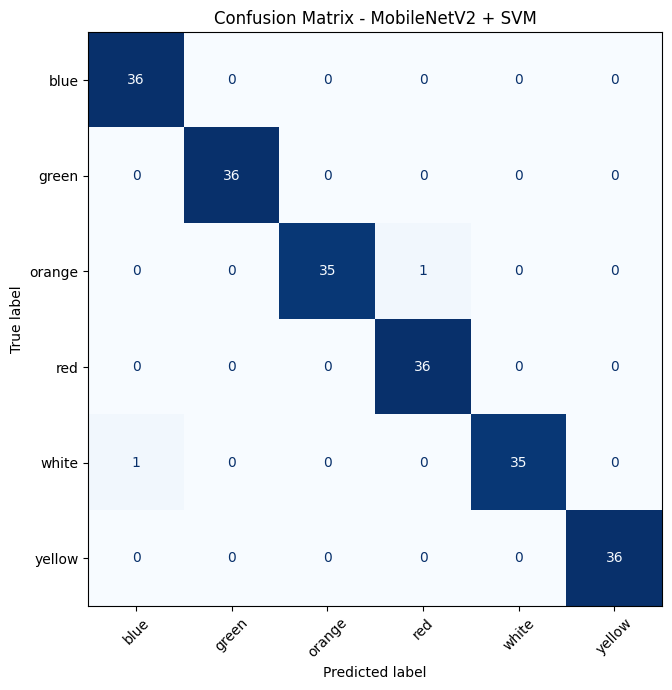

Saved confusion matrix: /content/drive/MyDrive/speedcube-colour-drifting/results/confusion_matrix_mobilenetv2_svm.png

Total wrong predictions: 2

Wrong prediction pairs:


,true_label,pred_label,count
0,orange,red,1
1,white,blue,1



Wrong prediction samples:


,sample_id,image_id,true_label,pred_label,roi_path
72,IMG_20260406_114714_r0_c0,white_IMG_20260406_114714,white,blue,/content/data/roi/white/IMG_20260406_114714_r0...
752,IMG_20260406_121404_r1_c2,orange_IMG_20260406_121404,orange,red,/content/data/roi/orange/IMG_20260406_121404_r...


Saved wrong prediction CSV: /content/drive/MyDrive/speedcube-colour-drifting/results/mobilenetv2_svm_wrong_predictions.csv


In [ ]:
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

# =========================
# Confusion Matrix
# =========================

cm_mobilenet_svm = confusion_matrix(
    y_test_mobilenet,
    test_pred_mobilenet_svm,
)

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm_mobilenet_svm,
    display_labels=label_encoder.classes_,
)

fig, ax = plt.subplots(figsize=(7, 7))

disp.plot(
    ax=ax,
    cmap="Blues",
    values_format="d",
    colorbar=False,
)

plt.title("Confusion Matrix - MobileNetV2 + SVM")
plt.xticks(rotation=45)
plt.tight_layout()

MOBILENET_SVM_CM_PATH = RESULTS_DIR / "confusion_matrix_mobilenetv2_svm.png"

plt.savefig(MOBILENET_SVM_CM_PATH, dpi=200)
plt.show()

print("Saved confusion matrix:", MOBILENET_SVM_CM_PATH)


# =========================
# Wrong Prediction Analysis
# =========================

mobilenet_error_df = mobilenet_test_data.copy()

mobilenet_error_df["true_label"] = label_encoder.inverse_transform(
    y_test_mobilenet
)

mobilenet_error_df["pred_label"] = label_encoder.inverse_transform(
    test_pred_mobilenet_svm
)

mobilenet_error_df["is_correct"] = (
    mobilenet_error_df["true_label"] == mobilenet_error_df["pred_label"]
)

wrong_mobilenet_df = mobilenet_error_df[
    mobilenet_error_df["is_correct"] == False
].copy()

print("\nTotal wrong predictions:", len(wrong_mobilenet_df))

print("\nWrong prediction pairs:")
display(
    wrong_mobilenet_df
    .groupby(["true_label", "pred_label"])
    .size()
    .reset_index(name="count")
    .sort_values("count", ascending=False)
)

print("\nWrong prediction samples:")
display(
    wrong_mobilenet_df[
        ["sample_id", "image_id", "true_label", "pred_label", "roi_path"]
    ]
)

MOBILENET_SVM_WRONG_PATH = RESULTS_DIR / "mobilenetv2_svm_wrong_predictions.csv"
wrong_mobilenet_df.to_csv(MOBILENET_SVM_WRONG_PATH, index=False)

print("Saved wrong prediction CSV:", MOBILENET_SVM_WRONG_PATH)

In [ ]:
import pandas as pd

RESULTS_DIR.mkdir(parents=True, exist_ok=True)

MODEL_COMPARISON_PATH = RESULTS_DIR / "model_comparison.csv"

model_comparison_records = [
    {
        "model": "SVM Grid Search",
        "category": "Machine Learning",
        "input": "24 color features",
        "test_accuracy": 0.9583333333333334,
        "test_precision_macro": 0.9666666666666667,
        "test_recall_macro": 0.9583333333333334,
        "test_f1_macro": 0.9576719576719577,
    },
    {
        "model": "SVM PSO",
        "category": "Machine Learning + Hyperparameter Tuning",
        "input": "24 color features",
        "test_accuracy": 0.9583333333333334,
        "test_precision_macro": 0.9666666666666667,
        "test_recall_macro": 0.9583333333333334,
        "test_f1_macro": 0.9576719576719577,
    },
    {
        "model": "MLP",
        "category": "Deep Learning",
        "input": "24 color features",
        "test_accuracy": 0.9537037037037037,
        "test_precision_macro": 0.9621621621621621,
        "test_recall_macro": 0.9537037037037037,
        "test_f1_macro": 0.953041434808751,
    },
    {
        "model": "MobileNetV2 + SVM",
        "category": "Transfer Learning + Machine Learning",
        "input": "MobileNetV2 1280 visual features",
        "test_accuracy": 0.9907407407407407,
        "test_precision_macro": 0.990990990990991,
        "test_recall_macro": 0.9907407407407408,
        "test_f1_macro": 0.9907389542735867,
    },
]

model_comparison_df = pd.DataFrame(model_comparison_records)
model_comparison_df.to_csv(MODEL_COMPARISON_PATH, index=False)

display(model_comparison_df)

print("Saved model comparison to:")
print(MODEL_COMPARISON_PATH)

,model,category,input,test_accuracy,test_precision_macro,test_recall_macro,test_f1_macro
0,SVM Grid Search,Machine Learning,24 color features,0.958333,0.966667,0.958333,0.957672
1,SVM PSO,Machine Learning + Hyperparameter Tuning,24 color features,0.958333,0.966667,0.958333,0.957672
2,MLP,Deep Learning,24 color features,0.953704,0.962162,0.953704,0.953041
3,MobileNetV2 + SVM,Transfer Learning + Machine Learning,MobileNetV2 1280 visual features,0.990741,0.990991,0.990741,0.990739


Saved model comparison to:
/content/drive/MyDrive/speedcube-colour-drifting/results/model_comparison.csv


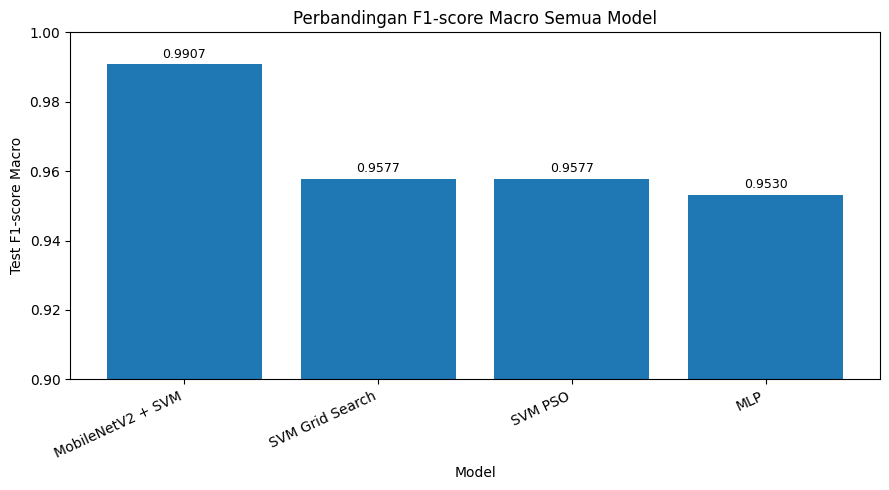

Saved F1 comparison chart:
/content/drive/MyDrive/speedcube-colour-drifting/results/f1_score_model_comparison.png


In [ ]:
import matplotlib.pyplot as plt
import pandas as pd

# Load comparison jika belum ada di memory
try:
    model_comparison_df
except NameError:
    MODEL_COMPARISON_PATH = RESULTS_DIR / "model_comparison.csv"
    model_comparison_df = pd.read_csv(MODEL_COMPARISON_PATH)

# Urutkan dari F1 tertinggi
plot_df = model_comparison_df.sort_values(
    "test_f1_macro",
    ascending=False,
).copy()

plt.figure(figsize=(9, 5))

plt.bar(
    plot_df["model"],
    plot_df["test_f1_macro"],
)

plt.title("Perbandingan F1-score Macro Semua Model")
plt.xlabel("Model")
plt.ylabel("Test F1-score Macro")
plt.ylim(0.90, 1.00)
plt.xticks(rotation=25, ha="right")

# Tampilkan nilai di atas bar
for index, value in enumerate(plot_df["test_f1_macro"]):
    plt.text(
        index,
        value + 0.002,
        f"{value:.4f}",
        ha="center",
        fontsize=9,
    )

plt.tight_layout()

F1_COMPARISON_CHART_PATH = RESULTS_DIR / "f1_score_model_comparison.png"
plt.savefig(F1_COMPARISON_CHART_PATH, dpi=200)
plt.show()

print("Saved F1 comparison chart:")
print(F1_COMPARISON_CHART_PATH)

,epoch,train_loss,train_accuracy,train_precision_macro,train_recall_macro,train_f1_macro,val_loss,val_accuracy,val_precision_macro,val_recall_macro,val_f1_macro
0,1,0.207790,0.928976,0.929222,0.928976,0.928964,0.048745,0.990741,0.990991,0.990741,0.990739
1,2,0.170475,0.938780,0.938988,0.938780,0.938767,0.030644,0.995370,0.995495,0.995370,0.995369
2,3,0.159308,0.940305,0.940271,0.940305,0.940276,0.027949,1.000000,1.000000,1.000000,1.000000
3,4,0.159604,0.937908,0.938017,0.937908,0.937913,0.030888,0.995370,0.995495,0.995370,0.995369
4,5,0.144108,0.945969,0.946218,0.945969,0.945949,0.026759,0.995370,0.995495,0.995370,0.995369


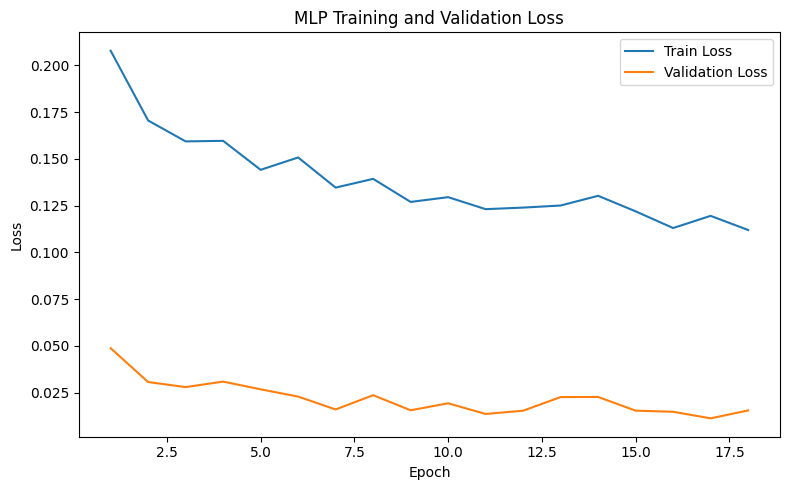

Saved loss curve: /content/drive/MyDrive/speedcube-colour-drifting/results/mlp_loss_curve.png


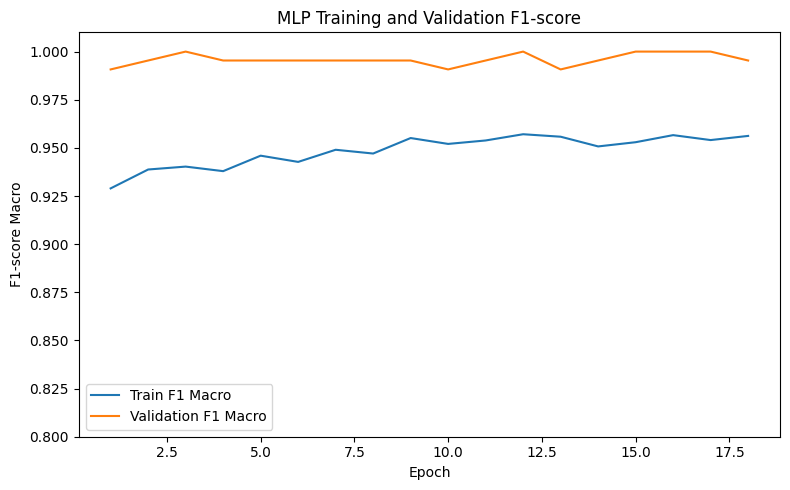

Saved F1 curve: /content/drive/MyDrive/speedcube-colour-drifting/results/mlp_f1_curve.png


In [ ]:
import pandas as pd
import matplotlib.pyplot as plt

# Load history kalau belum ada di memory
try:
    mlp_history_df
except NameError:
    try:
        mlp_history_df = pd.DataFrame(mlp_history)
    except NameError:
        MLP_HISTORY_PATH = RESULTS_DIR / "mlp_history.csv"
        mlp_history_df = pd.read_csv(MLP_HISTORY_PATH)

display(mlp_history_df.head())

# =========================
# Plot Loss Curve
# =========================

plt.figure(figsize=(8, 5))

plt.plot(
    mlp_history_df["epoch"],
    mlp_history_df["train_loss"],
    label="Train Loss",
)

plt.plot(
    mlp_history_df["epoch"],
    mlp_history_df["val_loss"],
    label="Validation Loss",
)

plt.title("MLP Training and Validation Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()
plt.tight_layout()

MLP_LOSS_CURVE_PATH = RESULTS_DIR / "mlp_loss_curve.png"
plt.savefig(MLP_LOSS_CURVE_PATH, dpi=200)
plt.show()

print("Saved loss curve:", MLP_LOSS_CURVE_PATH)


# =========================
# Plot F1 Curve
# =========================

plt.figure(figsize=(8, 5))

plt.plot(
    mlp_history_df["epoch"],
    mlp_history_df["train_f1_macro"],
    label="Train F1 Macro",
)

plt.plot(
    mlp_history_df["epoch"],
    mlp_history_df["val_f1_macro"],
    label="Validation F1 Macro",
)

plt.title("MLP Training and Validation F1-score")
plt.xlabel("Epoch")
plt.ylabel("F1-score Macro")
plt.ylim(0.80, 1.01)
plt.legend()
plt.tight_layout()

MLP_F1_CURVE_PATH = RESULTS_DIR / "mlp_f1_curve.png"
plt.savefig(MLP_F1_CURVE_PATH, dpi=200)
plt.show()

print("Saved F1 curve:", MLP_F1_CURVE_PATH)

# EfficientNetV2 + MLP

In [ ]:
import torch
import torch.nn as nn

from torchvision.models import efficientnet_v2_s, EfficientNet_V2_S_Weights

# =========================
# Device
# =========================

if torch.cuda.is_available():
    DEVICE = torch.device("cuda")
elif hasattr(torch.backends, "mps") and torch.backends.mps.is_available():
    DEVICE = torch.device("mps")
else:
    DEVICE = torch.device("cpu")

print("Device:", DEVICE)


# =========================
# Load EfficientNetV2-S
# =========================

efficientnet_weights = EfficientNet_V2_S_Weights.DEFAULT
efficientnet_preprocess = efficientnet_weights.transforms()

efficientnet = efficientnet_v2_s(weights=efficientnet_weights)

# Ambil feature extractor saja, classifier bawaan dibuang
efficientnet_feature_extractor = nn.Sequential(
    efficientnet.features,
    nn.AdaptiveAvgPool2d((1, 1)),
    nn.Flatten(),
).to(DEVICE)

# Freeze semua parameter
for param in efficientnet_feature_extractor.parameters():
    param.requires_grad = False

efficientnet_feature_extractor.eval()

print("EfficientNetV2-S feature extractor ready.")

# Cek dimensi output
with torch.no_grad():
    dummy = torch.zeros(1, 3, 384, 384).to(DEVICE)
    dummy_features = efficientnet_feature_extractor(dummy)

print("Output feature shape:", dummy_features.shape)

Device: cuda
EfficientNetV2-S feature extractor ready.
Output feature shape: torch.Size([1, 1280])


In [ ]:
from PIL import Image
from torch.utils.data import Dataset, DataLoader
import os

# =========================
# Split metadata
# =========================

efficientnet_train_data = features_df[features_df["split"] == "train"].copy()
efficientnet_val_data = features_df[features_df["split"] == "val"].copy()
efficientnet_test_data = features_df[features_df["split"] == "test"].copy()

print("Train:", efficientnet_train_data.shape)
print("Val  :", efficientnet_val_data.shape)
print("Test :", efficientnet_test_data.shape)


# =========================
# Check image paths
# =========================

missing_paths = []

for path in features_df["roi_path"].values:
    if not os.path.exists(path):
        missing_paths.append(path)

print("Missing image paths:", len(missing_paths))

if len(missing_paths) > 0:
    print("Example missing path:")
    print(missing_paths[0])


# =========================
# Dataset
# =========================

class EfficientNetROIDataset(Dataset):
    def __init__(self, dataframe, label_encoder, transform):
        self.dataframe = dataframe.reset_index(drop=True)
        self.label_encoder = label_encoder
        self.transform = transform

        self.paths = self.dataframe["roi_path"].values
        self.labels = self.label_encoder.transform(self.dataframe["label"].values)

    def __len__(self):
        return len(self.dataframe)

    def __getitem__(self, idx):
        image_path = self.paths[idx]

        image = Image.open(image_path).convert("RGB")
        image = self.transform(image)

        label = int(self.labels[idx])

        return image, label


# =========================
# DataLoader
# =========================

EFFICIENTNET_BATCH_SIZE = 32

pin_memory = True if DEVICE.type == "cuda" else False

efficientnet_train_dataset = EfficientNetROIDataset(
    dataframe=efficientnet_train_data,
    label_encoder=label_encoder,
    transform=efficientnet_preprocess,
)

efficientnet_val_dataset = EfficientNetROIDataset(
    dataframe=efficientnet_val_data,
    label_encoder=label_encoder,
    transform=efficientnet_preprocess,
)

efficientnet_test_dataset = EfficientNetROIDataset(
    dataframe=efficientnet_test_data,
    label_encoder=label_encoder,
    transform=efficientnet_preprocess,
)

efficientnet_train_loader = DataLoader(
    efficientnet_train_dataset,
    batch_size=EFFICIENTNET_BATCH_SIZE,
    shuffle=False,
    num_workers=2,
    pin_memory=pin_memory,
)

efficientnet_val_loader = DataLoader(
    efficientnet_val_dataset,
    batch_size=EFFICIENTNET_BATCH_SIZE,
    shuffle=False,
    num_workers=2,
    pin_memory=pin_memory,
)

efficientnet_test_loader = DataLoader(
    efficientnet_test_dataset,
    batch_size=EFFICIENTNET_BATCH_SIZE,
    shuffle=False,
    num_workers=2,
    pin_memory=pin_memory,
)

print("Train batches:", len(efficientnet_train_loader))
print("Val batches  :", len(efficientnet_val_loader))
print("Test batches :", len(efficientnet_test_loader))

Train: (4590, 31)
Val  : (216, 31)
Test : (216, 31)
Missing image paths: 0
Train batches: 144
Val batches  : 7
Test batches : 7


In [ ]:
from tqdm.auto import tqdm
import numpy as np
import torch

@torch.no_grad()
def extract_efficientnet_features(feature_extractor, dataloader, device):
    feature_extractor.eval()

    all_features = []
    all_labels = []

    for images, labels in tqdm(dataloader, desc="Extracting EfficientNetV2 features"):
        images = images.to(device, non_blocking=True)

        features = feature_extractor(images)

        all_features.append(features.cpu().numpy())
        all_labels.append(labels.numpy())

    all_features = np.concatenate(all_features, axis=0)
    all_labels = np.concatenate(all_labels, axis=0)

    return all_features, all_labels


X_train_effnet, y_train_effnet = extract_efficientnet_features(
    efficientnet_feature_extractor,
    efficientnet_train_loader,
    DEVICE,
)

X_val_effnet, y_val_effnet = extract_efficientnet_features(
    efficientnet_feature_extractor,
    efficientnet_val_loader,
    DEVICE,
)

X_test_effnet, y_test_effnet = extract_efficientnet_features(
    efficientnet_feature_extractor,
    efficientnet_test_loader,
    DEVICE,
)

print("X_train_effnet:", X_train_effnet.shape)
print("X_val_effnet  :", X_val_effnet.shape)
print("X_test_effnet :", X_test_effnet.shape)

print("y_train_effnet:", y_train_effnet.shape)
print("y_val_effnet  :", y_val_effnet.shape)
print("y_test_effnet :", y_test_effnet.shape)

Extracting EfficientNetV2 features:   0%|          | 0/144 [00:00<?, ?it/s]

Extracting EfficientNetV2 features:   0%|          | 0/7 [00:00<?, ?it/s]

Exception ignored in: <function _MultiProcessingDataLoaderIter.__del__ at 0x7d014c654ae0>
Traceback (most recent call last):
  File "/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py", line 1709, in __del__
    self._shutdown_workers()
  File "/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py", line 1655, in _shutdown_workers
    self._pin_memory_thread.join()
  File "/usr/lib/python3.12/threading.py", line 1146, in join
    raise RuntimeError("cannot join current thread")
RuntimeError: cannot join current thread
Exception ignored in: <function _MultiProcessingDataLoaderIter.__del__ at 0x7d014c654ae0>
Traceback (most recent call last):
  File "/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py", line 1709, in __del__
    self._shutdown_workers()
  File "/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py", line 1692, in _shutdown_workers
    if w.is_alive():
       ^^^^^^^^^^^^
  File "/usr/lib/python3.12/

Extracting EfficientNetV2 features:   0%|          | 0/7 [00:00<?, ?it/s]

X_train_effnet: (4590, 1280)
X_val_effnet  : (216, 1280)
X_test_effnet : (216, 1280)
y_train_effnet: (4590,)
y_val_effnet  : (216,)
y_test_effnet : (216,)


In [ ]:
import numpy as np

EFFICIENTNET_FEATURES_PATH = PROCESSED_DIR / "efficientnetv2_s_features.npz"

np.savez_compressed(
    EFFICIENTNET_FEATURES_PATH,

    X_train_effnet=X_train_effnet,
    y_train_effnet=y_train_effnet,

    X_val_effnet=X_val_effnet,
    y_val_effnet=y_val_effnet,

    X_test_effnet=X_test_effnet,
    y_test_effnet=y_test_effnet,

    train_sample_ids=efficientnet_train_data["sample_id"].values,
    val_sample_ids=efficientnet_val_data["sample_id"].values,
    test_sample_ids=efficientnet_test_data["sample_id"].values,

    classes=label_encoder.classes_,
)

print("Saved EfficientNetV2 features to:")
print(EFFICIENTNET_FEATURES_PATH)

Saved EfficientNetV2 features to:
/content/drive/MyDrive/speedcube-colour-drifting/processed/efficientnetv2_s_features.npz


In [ ]:
import random
import numpy as np
import torch
import torch.nn as nn

from sklearn.preprocessing import StandardScaler
from torch.utils.data import Dataset, DataLoader

# =========================
# Reproducibility
# =========================

def set_seed(seed=42):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)

    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False


set_seed(RANDOM_STATE)


# =========================
# Scale EfficientNetV2 Features
# =========================

effnet_scaler = StandardScaler()

X_train_effnet_scaled = effnet_scaler.fit_transform(X_train_effnet)
X_val_effnet_scaled = effnet_scaler.transform(X_val_effnet)
X_test_effnet_scaled = effnet_scaler.transform(X_test_effnet)

print("X_train_effnet_scaled:", X_train_effnet_scaled.shape)
print("X_val_effnet_scaled  :", X_val_effnet_scaled.shape)
print("X_test_effnet_scaled :", X_test_effnet_scaled.shape)


# =========================
# Dataset
# =========================

class EfficientNetFeatureDataset(Dataset):
    def __init__(self, X, y):
        self.X = torch.tensor(X, dtype=torch.float32)
        self.y = torch.tensor(y, dtype=torch.long)

    def __len__(self):
        return len(self.X)

    def __getitem__(self, idx):
        return self.X[idx], self.y[idx]


# =========================
# DataLoader
# =========================

EFFNET_MLP_BATCH_SIZE = 64

effnet_train_feature_dataset = EfficientNetFeatureDataset(
    X_train_effnet_scaled,
    y_train_effnet,
)

effnet_val_feature_dataset = EfficientNetFeatureDataset(
    X_val_effnet_scaled,
    y_val_effnet,
)

effnet_test_feature_dataset = EfficientNetFeatureDataset(
    X_test_effnet_scaled,
    y_test_effnet,
)

effnet_train_feature_loader = DataLoader(
    effnet_train_feature_dataset,
    batch_size=EFFNET_MLP_BATCH_SIZE,
    shuffle=True,
)

effnet_val_feature_loader = DataLoader(
    effnet_val_feature_dataset,
    batch_size=EFFNET_MLP_BATCH_SIZE,
    shuffle=False,
)

effnet_test_feature_loader = DataLoader(
    effnet_test_feature_dataset,
    batch_size=EFFNET_MLP_BATCH_SIZE,
    shuffle=False,
)

print("Train batches:", len(effnet_train_feature_loader))
print("Val batches  :", len(effnet_val_feature_loader))
print("Test batches :", len(effnet_test_feature_loader))

X_train_effnet_scaled: (4590, 1280)
X_val_effnet_scaled  : (216, 1280)
X_test_effnet_scaled : (216, 1280)
Train batches: 72
Val batches  : 4
Test batches : 4


In [ ]:
# =========================
# EfficientNetV2 Feature MLP Head
# =========================

class EfficientNetMLPHead(nn.Module):
    def __init__(self, input_dim=1280, num_classes=6, dropout=0.3):
        super().__init__()

        self.net = nn.Sequential(
            nn.Linear(input_dim, 256),
            nn.BatchNorm1d(256),
            nn.ReLU(),
            nn.Dropout(dropout),

            nn.Linear(256, 64),
            nn.BatchNorm1d(64),
            nn.ReLU(),
            nn.Dropout(dropout),

            nn.Linear(64, num_classes)
        )

    def forward(self, x):
        return self.net(x)


# =========================
# Model Config
# =========================

EFFNET_INPUT_DIM = X_train_effnet_scaled.shape[1]
EFFNET_NUM_CLASSES = len(label_encoder.classes_)

EFFNET_DROPOUT = 0.3
EFFNET_LEARNING_RATE = 1e-3
EFFNET_WEIGHT_DECAY = 1e-4

effnet_mlp_model = EfficientNetMLPHead(
    input_dim=EFFNET_INPUT_DIM,
    num_classes=EFFNET_NUM_CLASSES,
    dropout=EFFNET_DROPOUT,
).to(DEVICE)

effnet_mlp_criterion = nn.CrossEntropyLoss()

effnet_mlp_optimizer = torch.optim.Adam(
    effnet_mlp_model.parameters(),
    lr=EFFNET_LEARNING_RATE,
    weight_decay=EFFNET_WEIGHT_DECAY,
)

print(effnet_mlp_model)
print("Input dim:", EFFNET_INPUT_DIM)
print("Num classes:", EFFNET_NUM_CLASSES)
print("Device:", DEVICE)

EfficientNetMLPHead(
  (net): Sequential(
    (0): Linear(in_features=1280, out_features=256, bias=True)
    (1): BatchNorm1d(256, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (2): ReLU()
    (3): Dropout(p=0.3, inplace=False)
    (4): Linear(in_features=256, out_features=64, bias=True)
    (5): BatchNorm1d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (6): ReLU()
    (7): Dropout(p=0.3, inplace=False)
    (8): Linear(in_features=64, out_features=6, bias=True)
  )
)
Input dim: 1280
Num classes: 6
Device: cuda


In [ ]:
import copy
import time
import pandas as pd

# =========================
# Training Config
# =========================

EFFNET_MLP_MAX_EPOCHS = 100
EFFNET_MLP_PATIENCE = 15
EFFNET_MLP_MIN_DELTA = 1e-4

best_effnet_mlp_val_f1 = -1.0
best_effnet_mlp_epoch = -1
effnet_mlp_epochs_without_improvement = 0

best_effnet_mlp_state = None
effnet_mlp_history = []

start_time = time.time()

# =========================
# Training Loop
# =========================

for epoch in range(1, EFFNET_MLP_MAX_EPOCHS + 1):
    train_metrics = train_one_epoch_mlp(
        model=effnet_mlp_model,
        dataloader=effnet_train_feature_loader,
        criterion=effnet_mlp_criterion,
        optimizer=effnet_mlp_optimizer,
        device=DEVICE,
        grad_clip=1.0,
    )

    val_metrics = evaluate_mlp(
        model=effnet_mlp_model,
        dataloader=effnet_val_feature_loader,
        criterion=effnet_mlp_criterion,
        device=DEVICE,
    )

    current_val_f1 = val_metrics["f1_macro"]

    effnet_mlp_history.append({
        "epoch": epoch,

        "train_loss": train_metrics["loss"],
        "train_accuracy": train_metrics["accuracy"],
        "train_precision_macro": train_metrics["precision_macro"],
        "train_recall_macro": train_metrics["recall_macro"],
        "train_f1_macro": train_metrics["f1_macro"],

        "val_loss": val_metrics["loss"],
        "val_accuracy": val_metrics["accuracy"],
        "val_precision_macro": val_metrics["precision_macro"],
        "val_recall_macro": val_metrics["recall_macro"],
        "val_f1_macro": val_metrics["f1_macro"],
    })

    improved = current_val_f1 > best_effnet_mlp_val_f1 + EFFNET_MLP_MIN_DELTA

    if improved:
        best_effnet_mlp_val_f1 = current_val_f1
        best_effnet_mlp_epoch = epoch
        effnet_mlp_epochs_without_improvement = 0
        best_effnet_mlp_state = copy.deepcopy(effnet_mlp_model.state_dict())
    else:
        effnet_mlp_epochs_without_improvement += 1

    print(
        f"Epoch {epoch:03d} | "
        f"Train Loss: {train_metrics['loss']:.4f} | "
        f"Train F1: {train_metrics['f1_macro']:.4f} | "
        f"Val Loss: {val_metrics['loss']:.4f} | "
        f"Val F1: {val_metrics['f1_macro']:.4f} | "
        f"Best Val F1: {best_effnet_mlp_val_f1:.4f}"
    )

    if effnet_mlp_epochs_without_improvement >= EFFNET_MLP_PATIENCE:
        print(f"\nEarly stopping at epoch {epoch}.")
        break


effnet_mlp_training_time = time.time() - start_time

# =========================
# Restore Best Model
# =========================

effnet_mlp_model.load_state_dict(best_effnet_mlp_state)

print("\n=== EfficientNetV2 + MLP Training Finished ===")
print("Best epoch:", best_effnet_mlp_epoch)
print("Best validation F1 macro:", best_effnet_mlp_val_f1)
print("Training time:", effnet_mlp_training_time, "seconds")

Training:   0%|          | 0/72 [00:00<?, ?it/s]

Epoch 001 | Train Loss: 0.4738 | Train F1: 0.9044 | Val Loss: 0.0808 | Val F1: 0.9954 | Best Val F1: 0.9954


Training:   0%|          | 0/72 [00:00<?, ?it/s]

Epoch 002 | Train Loss: 0.1385 | Train F1: 0.9677 | Val Loss: 0.0683 | Val F1: 0.9768 | Best Val F1: 0.9954


Training:   0%|          | 0/72 [00:00<?, ?it/s]

...

Epoch 014 | Train Loss: 0.0412 | Train F1: 0.9845 | Val Loss: 0.0294 | Val F1: 0.9861 | Best Val F1: 0.9954


Training:   0%|          | 0/72 [00:00<?, ?it/s]

Epoch 015 | Train Loss: 0.0329 | Train F1: 0.9902 | Val Loss: 0.0417 | Val F1: 0.9815 | Best Val F1: 0.9954


Training:   0%|          | 0/72 [00:00<?, ?it/s]

Epoch 016 | Train Loss: 0.0359 | Train F1: 0.9874 | Val Loss: 0.0465 | Val F1: 0.9861 | Best Val F1: 0.9954

Early stopping at epoch 16.

=== EfficientNetV2 + MLP Training Finished ===
Best epoch: 1
Best validation F1 macro: 0.9953694771367934
Training time: 7.204281806945801 seconds


In [ ]:
effnet_mlp_val_metrics = evaluate_mlp(
    model=effnet_mlp_model,
    dataloader=effnet_val_feature_loader,
    criterion=effnet_mlp_criterion,
    device=DEVICE,
)

print("=== Validation Evaluation - EfficientNetV2 + MLP ===")
print("Loss            :", effnet_mlp_val_metrics["loss"])
print("Accuracy        :", effnet_mlp_val_metrics["accuracy"])
print("Precision macro :", effnet_mlp_val_metrics["precision_macro"])
print("Recall macro    :", effnet_mlp_val_metrics["recall_macro"])
print("F1 macro        :", effnet_mlp_val_metrics["f1_macro"])

print("\nValidation classification report:")
print(classification_report(
    effnet_mlp_val_metrics["y_true"],
    effnet_mlp_val_metrics["y_pred"],
    target_names=label_encoder.classes_,
    zero_division=0,
))

=== Validation Evaluation - EfficientNetV2 + MLP ===
Loss            : 0.0807886231276724
Accuracy        : 0.9953703703703703
Precision macro : 0.9954954954954954
Recall macro    : 0.9953703703703703
F1 macro        : 0.9953694771367934

Validation classification report:
              precision    recall  f1-score   support

        blue       1.00      1.00      1.00        36
       green       1.00      1.00      1.00        36
      orange       0.97      1.00      0.99        36
         red       1.00      0.97      0.99        36
       white       1.00      1.00      1.00        36
      yellow       1.00      1.00      1.00        36

    accuracy                           1.00       216
   macro avg       1.00      1.00      1.00       216
weighted avg       1.00      1.00      1.00       216



In [ ]:
effnet_mlp_test_metrics = evaluate_mlp(
    model=effnet_mlp_model,
    dataloader=effnet_test_feature_loader,
    criterion=effnet_mlp_criterion,
    device=DEVICE,
)

print("=== Final Test Evaluation - EfficientNetV2 + MLP ===")
print("Loss            :", effnet_mlp_test_metrics["loss"])
print("Accuracy        :", effnet_mlp_test_metrics["accuracy"])
print("Precision macro :", effnet_mlp_test_metrics["precision_macro"])
print("Recall macro    :", effnet_mlp_test_metrics["recall_macro"])
print("F1 macro        :", effnet_mlp_test_metrics["f1_macro"])

print("\nTest classification report:")
print(classification_report(
    effnet_mlp_test_metrics["y_true"],
    effnet_mlp_test_metrics["y_pred"],
    target_names=label_encoder.classes_,
    zero_division=0,
))

=== Final Test Evaluation - EfficientNetV2 + MLP ===
Loss            : 0.10557853623672768
Accuracy        : 1.0
Precision macro : 1.0
Recall macro    : 1.0
F1 macro        : 1.0

Test classification report:
              precision    recall  f1-score   support

        blue       1.00      1.00      1.00        36
       green       1.00      1.00      1.00        36
      orange       1.00      1.00      1.00        36
         red       1.00      1.00      1.00        36
       white       1.00      1.00      1.00        36
      yellow       1.00      1.00      1.00        36

    accuracy                           1.00       216
   macro avg       1.00      1.00      1.00       216
weighted avg       1.00      1.00      1.00       216



In [ ]:
# =========================
# Check image_id overlap
# =========================

train_image_ids = set(efficientnet_train_data["image_id"])
val_image_ids = set(efficientnet_val_data["image_id"])
test_image_ids = set(efficientnet_test_data["image_id"])

print("Train-Val image_id overlap :", len(train_image_ids & val_image_ids))
print("Train-Test image_id overlap:", len(train_image_ids & test_image_ids))
print("Val-Test image_id overlap  :", len(val_image_ids & test_image_ids))


# =========================
# Check source_id overlap if available
# =========================

if "source_id" in efficientnet_train_data.columns:
    train_source_ids = set(efficientnet_train_data["source_id"])
    val_source_ids = set(efficientnet_val_data["source_id"])
    test_source_ids = set(efficientnet_test_data["source_id"])

    print("\nTrain-Val source_id overlap :", len(train_source_ids & val_source_ids))
    print("Train-Test source_id overlap:", len(train_source_ids & test_source_ids))
    print("Val-Test source_id overlap  :", len(val_source_ids & test_source_ids))

Train-Val image_id overlap : 0
Train-Test image_id overlap: 0
Val-Test image_id overlap  : 0

Train-Val source_id overlap : 0
Train-Test source_id overlap: 0
Val-Test source_id overlap  : 0


In [ ]:
import pandas as pd
import torch
import joblib

effnet_mlp_result = {
    "model": "EfficientNetV2-S + MLP",
    "category": "Transfer Learning + Deep Learning",
    "input": "EfficientNetV2-S 1280 visual features",
    "best_epoch": best_effnet_mlp_epoch,
    "best_validation_f1_macro": best_effnet_mlp_val_f1,
    "validation_accuracy": effnet_mlp_val_metrics["accuracy"],
    "validation_precision_macro": effnet_mlp_val_metrics["precision_macro"],
    "validation_recall_macro": effnet_mlp_val_metrics["recall_macro"],
    "validation_f1_macro": effnet_mlp_val_metrics["f1_macro"],
    "test_accuracy": effnet_mlp_test_metrics["accuracy"],
    "test_precision_macro": effnet_mlp_test_metrics["precision_macro"],
    "test_recall_macro": effnet_mlp_test_metrics["recall_macro"],
    "test_f1_macro": effnet_mlp_test_metrics["f1_macro"],
    "training_time_seconds": effnet_mlp_training_time,
}

EFFNET_MLP_RESULT_PATH = RESULTS_DIR / "efficientnetv2_mlp_test_result.csv"
EFFNET_MLP_MODEL_PATH = MODELS_DIR / "efficientnetv2_mlp_head.pt"
EFFNET_MLP_SCALER_PATH = MODELS_DIR / "efficientnetv2_mlp_scaler.pkl"
EFFNET_MLP_HISTORY_PATH = RESULTS_DIR / "efficientnetv2_mlp_history.csv"

pd.DataFrame([effnet_mlp_result]).to_csv(EFFNET_MLP_RESULT_PATH, index=False)
pd.DataFrame(effnet_mlp_history).to_csv(EFFNET_MLP_HISTORY_PATH, index=False)

torch.save({
    "model_state_dict": effnet_mlp_model.state_dict(),
    "input_dim": EFFNET_INPUT_DIM,
    "num_classes": EFFNET_NUM_CLASSES,
    "dropout": EFFNET_DROPOUT,
    "classes": list(label_encoder.classes_),
}, EFFNET_MLP_MODEL_PATH)

joblib.dump(effnet_scaler, EFFNET_MLP_SCALER_PATH)

print("Saved result :", EFFNET_MLP_RESULT_PATH)
print("Saved history:", EFFNET_MLP_HISTORY_PATH)
print("Saved model  :", EFFNET_MLP_MODEL_PATH)
print("Saved scaler :", EFFNET_MLP_SCALER_PATH)

Saved result : /content/drive/MyDrive/speedcube-colour-drifting/results/efficientnetv2_mlp_test_result.csv
Saved history: /content/drive/MyDrive/speedcube-colour-drifting/results/efficientnetv2_mlp_history.csv
Saved model  : /content/drive/MyDrive/speedcube-colour-drifting/models/efficientnetv2_mlp_head.pt
Saved scaler : /content/drive/MyDrive/speedcube-colour-drifting/models/efficientnetv2_mlp_scaler.pkl


# Zum Dhiagramme

In [ ]:
import pandas as pd

RESULTS_DIR.mkdir(parents=True, exist_ok=True)

MODEL_COMPARISON_PATH = RESULTS_DIR / "model_comparison.csv"

model_comparison_records = [
    {
        "model": "SVM Grid Search",
        "category": "Machine Learning",
        "input": "24 color features",
        "test_accuracy": 0.9583333333333334,
        "test_precision_macro": 0.9666666666666667,
        "test_recall_macro": 0.9583333333333334,
        "test_f1_macro": 0.9576719576719577,
    },
    {
        "model": "SVM PSO",
        "category": "Machine Learning + Tuning",
        "input": "24 color features",
        "test_accuracy": 0.9583333333333334,
        "test_precision_macro": 0.9666666666666667,
        "test_recall_macro": 0.9583333333333334,
        "test_f1_macro": 0.9576719576719577,
    },
    {
        "model": "MLP",
        "category": "Deep Learning",
        "input": "24 color features",
        "test_accuracy": 0.9537037037037037,
        "test_precision_macro": 0.9621621621621621,
        "test_recall_macro": 0.9537037037037037,
        "test_f1_macro": 0.953041434808751,
    },
    {
        "model": "MobileNetV2 + SVM",
        "category": "Transfer Learning + ML",
        "input": "MobileNetV2 1280 visual features",
        "test_accuracy": 0.9907407407407407,
        "test_precision_macro": 0.990990990990991,
        "test_recall_macro": 0.9907407407407408,
        "test_f1_macro": 0.9907389542735867,
    },
    {
        "model": "EfficientNetV2-S + MLP",
        "category": "Transfer Learning + DL",
        "input": "EfficientNetV2-S 1280 visual features",
        "test_accuracy": 1.0,
        "test_precision_macro": 1.0,
        "test_recall_macro": 1.0,
        "test_f1_macro": 1.0,
    },
]

model_comparison_df = pd.DataFrame(model_comparison_records)
model_comparison_df.to_csv(MODEL_COMPARISON_PATH, index=False)

display(model_comparison_df)

print("Saved:", MODEL_COMPARISON_PATH)

,model,category,input,test_accuracy,test_precision_macro,test_recall_macro,test_f1_macro
0,SVM Grid Search,Machine Learning,24 color features,0.958333,0.966667,0.958333,0.957672
1,SVM PSO,Machine Learning + Tuning,24 color features,0.958333,0.966667,0.958333,0.957672
2,MLP,Deep Learning,24 color features,0.953704,0.962162,0.953704,0.953041
3,MobileNetV2 + SVM,Transfer Learning + ML,MobileNetV2 1280 visual features,0.990741,0.990991,0.990741,0.990739
4,EfficientNetV2-S + MLP,Transfer Learning + DL,EfficientNetV2-S 1280 visual features,1.000000,1.000000,1.000000,1.000000


Saved: /content/drive/MyDrive/speedcube-colour-drifting/results/model_comparison.csv


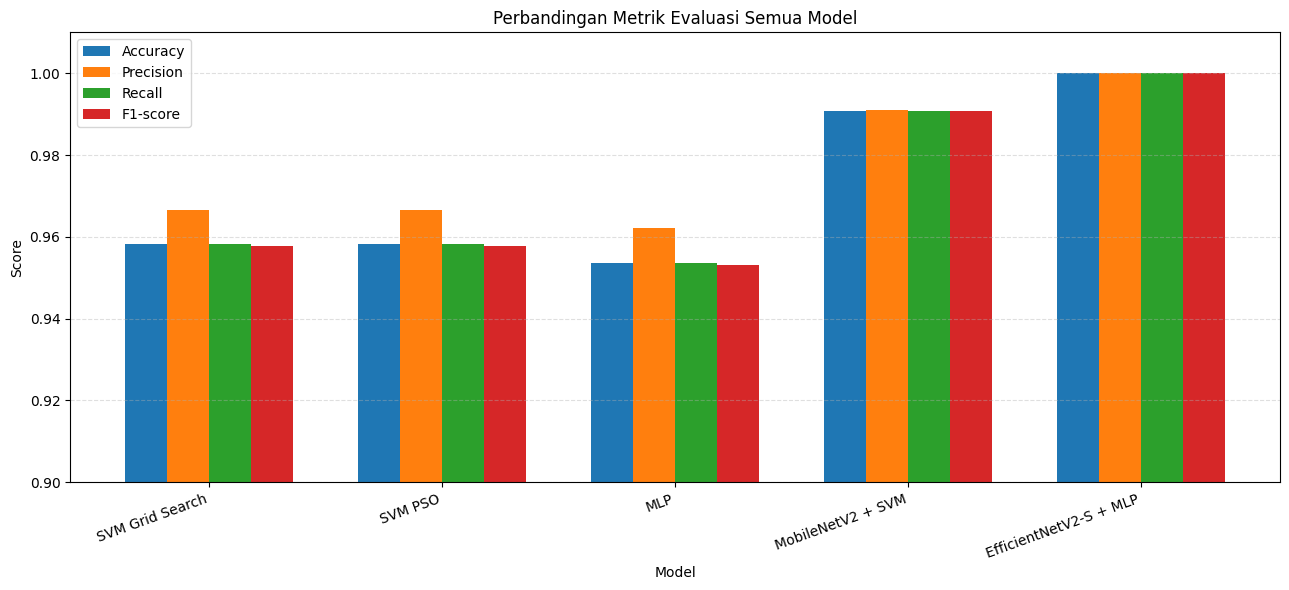

Saved: /content/drive/MyDrive/speedcube-colour-drifting/results/metrics_comparison_all_models.png


In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd

try:
    model_comparison_df
except NameError:
    model_comparison_df = pd.read_csv(MODEL_COMPARISON_PATH)

plot_df = model_comparison_df.copy()

metrics = [
    "test_accuracy",
    "test_precision_macro",
    "test_recall_macro",
    "test_f1_macro",
]

metric_labels = [
    "Accuracy",
    "Precision",
    "Recall",
    "F1-score",
]

x = np.arange(len(plot_df["model"]))
bar_width = 0.18

plt.figure(figsize=(13, 6))

for i, metric in enumerate(metrics):
    plt.bar(
        x + (i - 1.5) * bar_width,
        plot_df[metric],
        width=bar_width,
        label=metric_labels[i],
    )

plt.title("Perbandingan Metrik Evaluasi Semua Model")
plt.xlabel("Model")
plt.ylabel("Score")
plt.xticks(x, plot_df["model"], rotation=20, ha="right")
plt.ylim(0.90, 1.01)
plt.legend()
plt.grid(axis="y", linestyle="--", alpha=0.4)
plt.tight_layout()

METRICS_COMPARISON_PATH = RESULTS_DIR / "metrics_comparison_all_models.png"
plt.savefig(METRICS_COMPARISON_PATH, dpi=200)
plt.show()

print("Saved:", METRICS_COMPARISON_PATH)

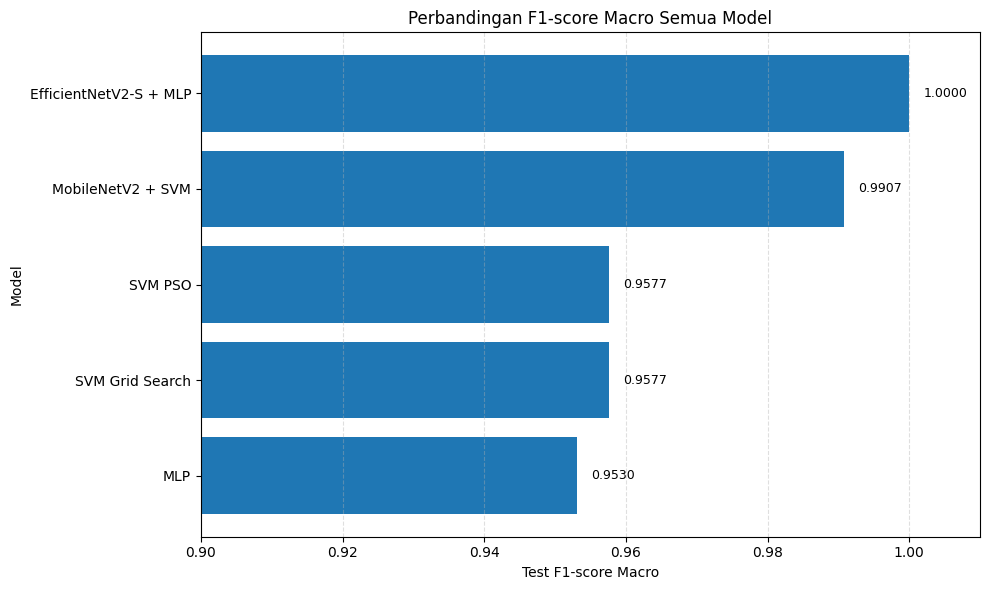

Saved: /content/drive/MyDrive/speedcube-colour-drifting/results/f1_score_comparison_all_models.png


In [ ]:
import matplotlib.pyplot as plt
import pandas as pd

try:
    model_comparison_df
except NameError:
    model_comparison_df = pd.read_csv(MODEL_COMPARISON_PATH)

plot_df = model_comparison_df.sort_values(
    "test_f1_macro",
    ascending=True,
).copy()

plt.figure(figsize=(10, 6))

plt.barh(
    plot_df["model"],
    plot_df["test_f1_macro"],
)

plt.title("Perbandingan F1-score Macro Semua Model")
plt.xlabel("Test F1-score Macro")
plt.ylabel("Model")
plt.xlim(0.90, 1.01)
plt.grid(axis="x", linestyle="--", alpha=0.4)

for index, value in enumerate(plot_df["test_f1_macro"]):
    plt.text(
        value + 0.002,
        index,
        f"{value:.4f}",
        va="center",
        fontsize=9,
    )

plt.tight_layout()

F1_COMPARISON_PATH = RESULTS_DIR / "f1_score_comparison_all_models.png"
plt.savefig(F1_COMPARISON_PATH, dpi=200)
plt.show()

print("Saved:", F1_COMPARISON_PATH)

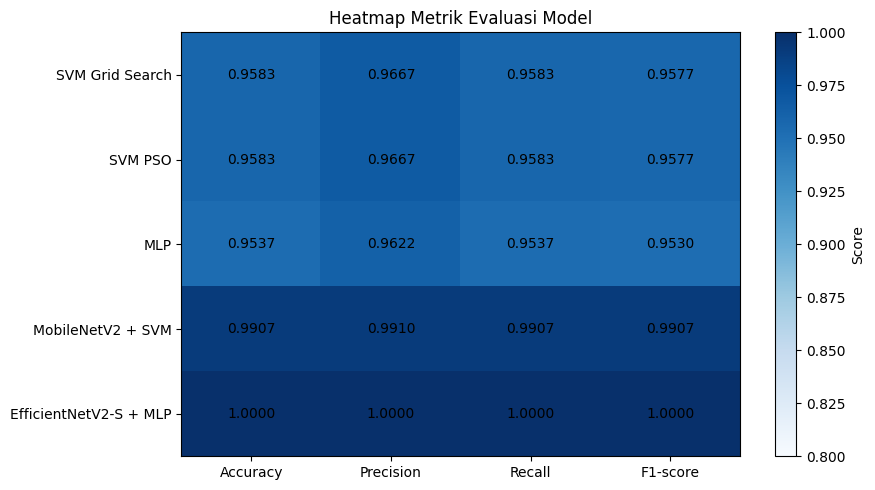

Saved: /content/drive/MyDrive/speedcube-colour-drifting/results/metrics_heatmap_all_models.png


In [ ]:
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np

try:
    model_comparison_df
except NameError:
    model_comparison_df = pd.read_csv(MODEL_COMPARISON_PATH)

heatmap_df = model_comparison_df[
    [
        "model",
        "test_accuracy",
        "test_precision_macro",
        "test_recall_macro",
        "test_f1_macro",
    ]
].copy()

heatmap_df = heatmap_df.set_index("model")

display_labels = [
    "Accuracy",
    "Precision",
    "Recall",
    "F1-score",
]

plt.figure(figsize=(9, 5))

plt.imshow(
    heatmap_df.values,
    aspect="auto",
    vmin=0.8,
    vmax=1.0,
    cmap="Blues"
)

plt.xticks(
    ticks=np.arange(len(display_labels)),
    labels=display_labels,
)

plt.yticks(
    ticks=np.arange(len(heatmap_df.index)),
    labels=heatmap_df.index,
)

plt.colorbar(label="Score")
plt.title("Heatmap Metrik Evaluasi Model")

for i in range(heatmap_df.shape[0]):
    for j in range(heatmap_df.shape[1]):
        plt.text(
            j,
            i,
            f"{heatmap_df.values[i, j]:.4f}",
            ha="center",
            va="center",
        )

plt.tight_layout()

METRICS_HEATMAP_PATH = RESULTS_DIR / "metrics_heatmap_all_models.png"
plt.savefig(METRICS_HEATMAP_PATH, dpi=200)
plt.show()

print("Saved:", METRICS_HEATMAP_PATH)

In [ ]:
# =========================
# Sanity Check: image_id overlap
# =========================

train_image_ids = set(efficientnet_train_data["image_id"])
val_image_ids = set(efficientnet_val_data["image_id"])
test_image_ids = set(efficientnet_test_data["image_id"])

print("=== image_id overlap ===")
print("Train-Val image_id overlap :", len(train_image_ids & val_image_ids))
print("Train-Test image_id overlap:", len(train_image_ids & test_image_ids))
print("Val-Test image_id overlap  :", len(val_image_ids & test_image_ids))


# =========================
# Sanity Check: source_id overlap
# =========================

if "source_id" in efficientnet_train_data.columns:
    train_source_ids = set(efficientnet_train_data["source_id"])
    val_source_ids = set(efficientnet_val_data["source_id"])
    test_source_ids = set(efficientnet_test_data["source_id"])

    print("\n=== source_id overlap ===")
    print("Train-Val source_id overlap :", len(train_source_ids & val_source_ids))
    print("Train-Test source_id overlap:", len(train_source_ids & test_source_ids))
    print("Val-Test source_id overlap  :", len(val_source_ids & test_source_ids))
else:
    print("\nColumn source_id tidak ada, skip source_id check.")

=== image_id overlap ===
Train-Val image_id overlap : 0
Train-Test image_id overlap: 0
Val-Test image_id overlap  : 0

=== source_id overlap ===
Train-Val source_id overlap : 0
Train-Test source_id overlap: 0
Val-Test source_id overlap  : 0


In [3]:
import joblib
import numpy as np
import pandas as pd
import torch
import torch.nn as nn
import matplotlib.pyplot as plt

from pathlib import Path
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay, classification_report


# =========================
# Paths
# =========================

BASE_DIR = Path("/content/drive/MyDrive/speedcube-colour-drifting")

PROCESSED_DIR = BASE_DIR / "processed"
MODELS_DIR = BASE_DIR / "models"
RESULTS_DIR = BASE_DIR / "results"

CONFUSION_MATRIX_DIR = RESULTS_DIR / "confusion_matrices"
CONFUSION_MATRIX_DIR.mkdir(parents=True, exist_ok=True)

FEATURES_PATH = PROCESSED_DIR / "features_24.csv"
EFFNET_FEATURES_PATH = PROCESSED_DIR / "efficientnetv2_s_features.npz"

MLP_MODEL_PATH = MODELS_DIR / "mlp_24_features.pt"
MLP_SCALER_PATH = MODELS_DIR / "mlp_scaler.pkl"

EFFNET_MLP_MODEL_PATH = MODELS_DIR / "efficientnetv2_mlp_head.pt"
EFFNET_MLP_SCALER_PATH = MODELS_DIR / "efficientnetv2_mlp_scaler.pkl"

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")

print("Device:", DEVICE)
print("MLP model exists:", MLP_MODEL_PATH.exists())
print("MLP scaler exists:", MLP_SCALER_PATH.exists())
print("EffNet model exists:", EFFNET_MLP_MODEL_PATH.exists())
print("EffNet scaler exists:", EFFNET_MLP_SCALER_PATH.exists())
print("EffNet features exists:", EFFNET_FEATURES_PATH.exists())

Device: cpu
MLP model exists: True
MLP scaler exists: True
EffNet model exists: True
EffNet scaler exists: True
EffNet features exists: True


Loaded MLP model.
Classes: ['blue', 'green', 'orange', 'red', 'white', 'yellow']
=== Classification Report - MLP ===
              precision    recall  f1-score   support

        blue       1.00      0.75      0.86        36
       green       1.00      1.00      1.00        36
      orange       0.97      1.00      0.99        36
         red       1.00      0.97      0.99        36
       white       0.80      1.00      0.89        36
      yellow       1.00      1.00      1.00        36

    accuracy                           0.95       216
   macro avg       0.96      0.95      0.95       216
weighted avg       0.96      0.95      0.95       216



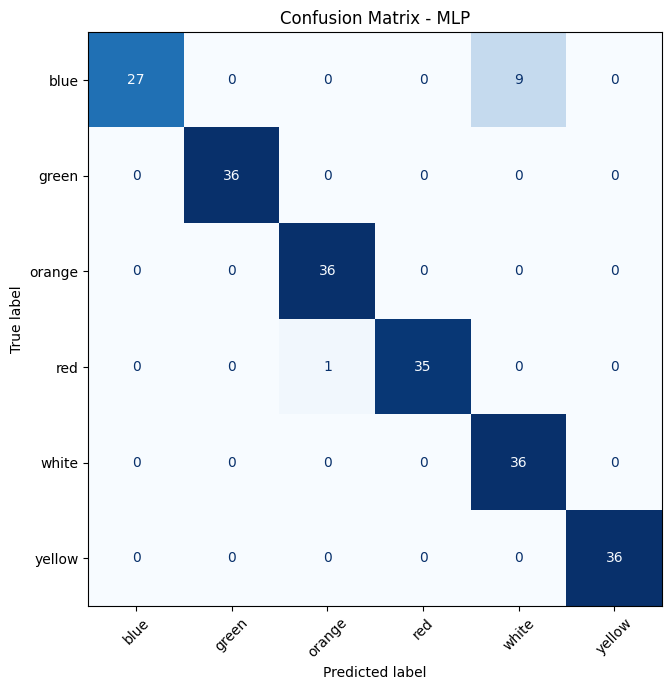

Saved: /content/drive/MyDrive/speedcube-colour-drifting/results/confusion_matrices/confusion_matrix_mlp.png


In [4]:
# =========================
# MLP 24 Features Model Definition
# =========================

class MLPColorClassifier(nn.Module):
    def __init__(self, input_dim=24, num_classes=6, dropout=0.2):
        super().__init__()

        self.net = nn.Sequential(
            nn.Linear(input_dim, 64),
            nn.BatchNorm1d(64),
            nn.ReLU(),
            nn.Dropout(dropout),

            nn.Linear(64, 32),
            nn.BatchNorm1d(32),
            nn.ReLU(),
            nn.Dropout(dropout),

            nn.Linear(32, num_classes),
        )

    def forward(self, x):
        return self.net(x)


# =========================
# Load MLP checkpoint
# =========================

try:
    mlp_checkpoint = torch.load(
        MLP_MODEL_PATH,
        map_location=DEVICE,
        weights_only=False,
    )
except TypeError:
    mlp_checkpoint = torch.load(
        MLP_MODEL_PATH,
        map_location=DEVICE,
    )

mlp_classes = list(mlp_checkpoint["classes"])
mlp_feature_columns = list(mlp_checkpoint["feature_columns"])
mlp_input_dim = mlp_checkpoint["input_dim"]
mlp_num_classes = mlp_checkpoint["num_classes"]
mlp_dropout = mlp_checkpoint["dropout"]

mlp_scaler = joblib.load(MLP_SCALER_PATH)

mlp_model = MLPColorClassifier(
    input_dim=mlp_input_dim,
    num_classes=mlp_num_classes,
    dropout=mlp_dropout,
).to(DEVICE)

mlp_model.load_state_dict(mlp_checkpoint["model_state_dict"])
mlp_model.eval()

print("Loaded MLP model.")
print("Classes:", mlp_classes)


# =========================
# Load test data
# =========================

features_df = pd.read_csv(FEATURES_PATH)
test_data = features_df[features_df["split"] == "test"].copy()

X_test_mlp = test_data[mlp_feature_columns].values
X_test_mlp_scaled = mlp_scaler.transform(X_test_mlp)

class_to_idx = {label: idx for idx, label in enumerate(mlp_classes)}
y_test_mlp = test_data["label"].map(class_to_idx).values

X_test_tensor = torch.tensor(
    X_test_mlp_scaled,
    dtype=torch.float32,
).to(DEVICE)

# =========================
# Predict
# =========================

with torch.no_grad():
    logits = mlp_model(X_test_tensor)
    y_pred_mlp = torch.argmax(logits, dim=1).cpu().numpy()

print("=== Classification Report - MLP ===")
print(classification_report(
    y_test_mlp,
    y_pred_mlp,
    target_names=mlp_classes,
    zero_division=0,
))


# =========================
# Confusion Matrix
# =========================

cm_mlp = confusion_matrix(
    y_test_mlp,
    y_pred_mlp,
)

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm_mlp,
    display_labels=mlp_classes,
)

fig, ax = plt.subplots(figsize=(7, 7))

disp.plot(
    ax=ax,
    cmap="Blues",
    values_format="d",
    colorbar=False,
)

plt.title("Confusion Matrix - MLP")
plt.xticks(rotation=45)
plt.tight_layout()

MLP_CM_PATH = CONFUSION_MATRIX_DIR / "confusion_matrix_mlp.png"

plt.savefig(MLP_CM_PATH, dpi=200)
plt.show()

print("Saved:", MLP_CM_PATH)

Loaded EfficientNetV2-S + MLP model.
Classes: ['blue', 'green', 'orange', 'red', 'white', 'yellow']
=== Classification Report - EfficientNetV2-S + MLP ===
              precision    recall  f1-score   support

        blue       1.00      1.00      1.00        36
       green       1.00      1.00      1.00        36
      orange       1.00      1.00      1.00        36
         red       1.00      1.00      1.00        36
       white       1.00      1.00      1.00        36
      yellow       1.00      1.00      1.00        36

    accuracy                           1.00       216
   macro avg       1.00      1.00      1.00       216
weighted avg       1.00      1.00      1.00       216



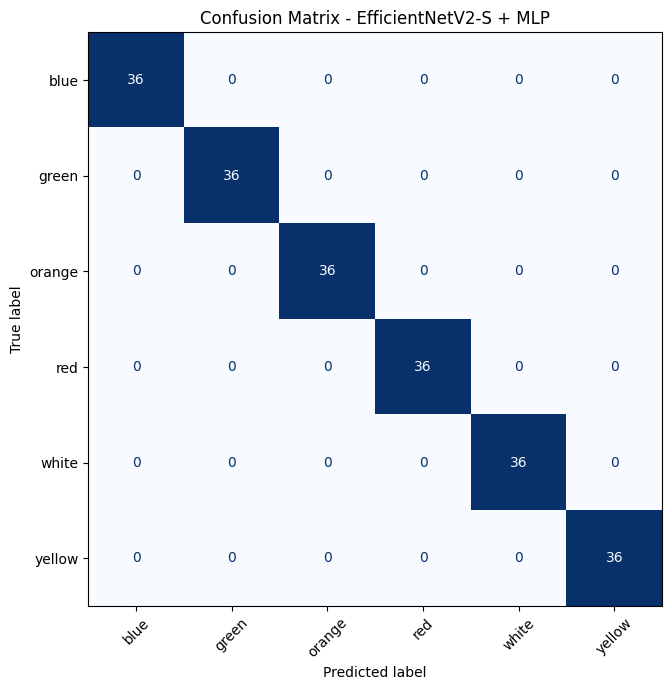

Saved: /content/drive/MyDrive/speedcube-colour-drifting/results/confusion_matrices/confusion_matrix_efficientnetv2_mlp.png


In [5]:
# =========================
# EfficientNetV2-S + MLP Head Definition
# =========================

class EfficientNetMLPHead(nn.Module):
    def __init__(self, input_dim=1280, num_classes=6, dropout=0.3):
        super().__init__()

        self.net = nn.Sequential(
            nn.Linear(input_dim, 256),
            nn.BatchNorm1d(256),
            nn.ReLU(),
            nn.Dropout(dropout),

            nn.Linear(256, 64),
            nn.BatchNorm1d(64),
            nn.ReLU(),
            nn.Dropout(dropout),

            nn.Linear(64, num_classes),
        )

    def forward(self, x):
        return self.net(x)


# =========================
# Load EfficientNetV2-S + MLP checkpoint
# =========================

try:
    effnet_checkpoint = torch.load(
        EFFNET_MLP_MODEL_PATH,
        map_location=DEVICE,
        weights_only=False,
    )
except TypeError:
    effnet_checkpoint = torch.load(
        EFFNET_MLP_MODEL_PATH,
        map_location=DEVICE,
    )

effnet_classes = list(effnet_checkpoint["classes"])
effnet_input_dim = effnet_checkpoint["input_dim"]
effnet_num_classes = effnet_checkpoint["num_classes"]
effnet_dropout = effnet_checkpoint["dropout"]

effnet_scaler = joblib.load(EFFNET_MLP_SCALER_PATH)

effnet_mlp_model = EfficientNetMLPHead(
    input_dim=effnet_input_dim,
    num_classes=effnet_num_classes,
    dropout=effnet_dropout,
).to(DEVICE)

effnet_mlp_model.load_state_dict(effnet_checkpoint["model_state_dict"])
effnet_mlp_model.eval()

print("Loaded EfficientNetV2-S + MLP model.")
print("Classes:", effnet_classes)


# =========================
# Load saved EfficientNetV2-S features
# =========================

loaded_effnet = np.load(EFFNET_FEATURES_PATH, allow_pickle=True)

X_test_effnet = loaded_effnet["X_test_effnet"]
y_test_effnet = loaded_effnet["y_test_effnet"]

X_test_effnet_scaled = effnet_scaler.transform(X_test_effnet)

X_test_effnet_tensor = torch.tensor(
    X_test_effnet_scaled,
    dtype=torch.float32,
).to(DEVICE)

# =========================
# Predict
# =========================

with torch.no_grad():
    logits = effnet_mlp_model(X_test_effnet_tensor)
    y_pred_effnet_mlp = torch.argmax(logits, dim=1).cpu().numpy()

print("=== Classification Report - EfficientNetV2-S + MLP ===")
print(classification_report(
    y_test_effnet,
    y_pred_effnet_mlp,
    target_names=effnet_classes,
    zero_division=0,
))


# =========================
# Confusion Matrix
# =========================

cm_effnet_mlp = confusion_matrix(
    y_test_effnet,
    y_pred_effnet_mlp,
)

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm_effnet_mlp,
    display_labels=effnet_classes,
)

fig, ax = plt.subplots(figsize=(7, 7))

disp.plot(
    ax=ax,
    cmap="Blues",
    values_format="d",
    colorbar=False,
)

plt.title("Confusion Matrix - EfficientNetV2-S + MLP")
plt.xticks(rotation=45)
plt.tight_layout()

EFFNET_MLP_CM_PATH = CONFUSION_MATRIX_DIR / "confusion_matrix_efficientnetv2_mlp.png"

plt.savefig(EFFNET_MLP_CM_PATH, dpi=200)
plt.show()

print("Saved:", EFFNET_MLP_CM_PATH)